In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
vbookshelf_respiratory_sound_database_path = kagglehub.dataset_download('vbookshelf/respiratory-sound-database')
apoorvagondane_covid_19_cough_classification_processed_path = kagglehub.dataset_download('apoorvagondane/covid-19-cough-classification-processed')

print('Data source import complete.')


100%|██████████| 3.69G/3.69G [01:03<00:00, 62.8MB/s]

Extracting files...


100%|██████████| 30.5M/30.5M [00:00<00:00, 184MB/s]

Extracting files...


Data source import complete.


# Notebook Completo - Treino Anti-Viés com 3 Classes Balanceadas

Este notebook implementa todas as soluções para resolver o viés do modelo, garantindo:
- ✅ 3 classes finais: **Pneumonia** (0), **Bronquite** (1), **Normal** (2)
- ✅ Todo processamento ANTES do treino: Balanceamento, augmentation, expansão
- ✅ Matriz de confusão 3x3 completa
- ✅ Dados de treino já balanceados (~150 amostras por classe)

## Estrutura:
1. **Fase 1**: Setup e Carregamento Inicial
2. **Fase 2**: Processamento e Balanceamento (ANTES DO TREINO)
3. **Fase 3**: Treino do Modelo
4. **Fase 4**: Avaliação e Exportação


## FASE 1: Setup e Carregamento Inicial

### Célula 0: Setup Inicial
Configuração de ambiente, dependências e paths.


In [2]:
import os
import sys
from pathlib import Path

# --- CONFIGURAÇÃO DE AMBIENTE ---
ENV_TYPE = 'kaggle'
REPO_NAME = "tosse"
PROJECT_ROOT = Path(f'/kaggle/working/{REPO_NAME}')
DATASET_INPUT_PATH = Path('/kaggle/input/icbhi-2017-respiratory-sound-database')
OUTPUT_DIR = Path("/kaggle/working/processed_data")

# Instala dependências necessárias
%pip install -q --upgrade pip
%pip install -q "protobuf<4.21.0"
%pip install -q librosa scipy scikit-learn tqdm imbalanced-learn
%pip install -q librosa scipy scikit-learn tqdm noisereduce

# Clonar repositório
if os.path.exists(PROJECT_ROOT):
    print(f"Limpando diretório antigo: {PROJECT_ROOT}")
    !rm -rf {PROJECT_ROOT}

print(f"Clonando repositório: https://github.com/joelcalolo/tosse.git")
!git clone https://github.com/joelcalolo/tosse.git {PROJECT_ROOT}

# Adicionar ao path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Verificar GPU
import tensorflow as tf
print(f"\n✅ TensorFlow version: {tf.__version__}")
print(f"✅ GPU disponível: {tf.config.list_physical_devices('GPU')}")
print(f"✅ PROJECT_ROOT: {PROJECT_ROOT}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 63.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.3 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
ydf 0.14.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.
Clonando repositório: https://github.com/joelcalolo/tosse.git
Cloning into '/kaggle/working/tosse'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing obje

### Célula 1: Configuração de Datasets
Localiza e verifica os datasets disponíveis.


In [3]:
import os
import json
from pathlib import Path
import pandas as pd

# Definir caminhos
# Usar o caminho fornecido por kagglehub
DATASET_INPUT_PATH = Path(vbookshelf_respiratory_sound_database_path)
DATA_DIR = DATASET_INPUT_PATH

print(f"🔍 Verificando pasta: {DATASET_INPUT_PATH}")

if not DATASET_INPUT_PATH.exists():
    print("❌ ERRO: A pasta não foi encontrada.")
    print("Pastas disponíveis no input:")
    !ls /kaggle/input/
else:
    print(f"✅ Pasta detectada com sucesso!")

    # Localizar arquivo de diagnósticos
    try:
        diagnosis_files = list(DATASET_INPUT_PATH.glob('**/patient_diagnosis.csv'))

        if diagnosis_files:
            diagnosis_file = diagnosis_files[0]
            print(f"✅ Arquivo de diagnósticos encontrado em: {diagnosis_file}")

            df_check = pd.read_csv(diagnosis_file, header=None, names=['Patient_ID', 'Diagnosis'])
            print("\nExemplo de diagnósticos carregados:")
            print(df_check.head())
            print(f"\n📊 Diagnósticos únicos disponíveis:")
            print(df_check['Diagnosis'].value_counts())
        else:
            print("⚠️ ERRO: O ficheiro 'patient_diagnosis.csv' não foi encontrado.")
    except Exception as e:
        print(f"❌ Erro ao procurar o ficheiro: {e}")

print(f"\n🚀 TUDO PRONTO PARA PROCESSAMENTO.")

🔍 Verificando pasta: /root/.cache/kagglehub/datasets/vbookshelf/respiratory-sound-database/versions/2
✅ Pasta detectada com sucesso!
✅ Arquivo de diagnósticos encontrado em: /root/.cache/kagglehub/datasets/vbookshelf/respiratory-sound-database/versions/2/respiratory_sound_database/Respiratory_Sound_Database/patient_diagnosis.csv

Exemplo de diagnósticos carregados:
   Patient_ID Diagnosis
0         101      URTI
1         102   Healthy
2         103    Asthma
3         104      COPD
4         105      URTI

📊 Diagnósticos únicos disponíveis:
Diagnosis
COPD              64
Healthy           26
URTI              14
Bronchiectasis     7
Bronchiolitis      6
Pneumonia          6
LRTI               2
Asthma             1
Name: count, dtype: int64

🚀 TUDO PRONTO PARA PROCESSAMENTO.


### Célula 2: Processamento ICBHI Expandido
Processa ICBHI com TODOS os diagnósticos e mapeia para 3 classes:
- **Pneumonia** (Classe 0): Pneumonia, URTI
- **Bronquite** (Classe 1): Bronchiolitis, Bronchitis, COPD, Asthma
- **Normal** (Classe 2): Healthy


In [4]:
import importlib
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import os
import re

# Ensure PROJECT_ROOT is in sys.path for proper module imports
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

# Define the full module path
module_full_path = 'src.data.process_icbhi_dataset'
script_file_path = Path(PROJECT_ROOT) / 'src' / 'data' / 'process_icbhi_dataset.py'

# Dynamically import the module to ensure it's loaded as a module object
# Remove from sys.modules if it was previously loaded to ensure a clean re-import
if module_full_path in sys.modules:
    del sys.modules[module_full_path]

import importlib.util
spec = importlib.util.spec_from_file_location(module_full_path, script_file_path)
process_icbhi_module = importlib.util.module_from_spec(spec)
sys.modules[module_full_path] = process_icbhi_module
spec.loader.exec_module(process_icbhi_module)


# Caminho do dataset
ICBHI_DATA_DIR = DATASET_INPUT_PATH

# --- Robust Strategy: Directly modify the module's source file to bypass filtering ---

# Read the original script content
with open(script_file_path, 'r') as f:
    original_script_content = f.read()

modified_script_content = original_script_content

# Pattern to find the diagnosis filtering line
# This regex is designed to catch variations of `df_filtered = df_diagnosis[df_diagnosis['Diagnosis'].isin(DIAGNOSES_TO_PROCESS)]`
# and similar filtering logic.
search_pattern_df_filter = r"(df_filtered\s*=\s*df_diagnosis\[df_diagnosis\['Diagnosis'\]\.isin\([\s\S]*?\)\])"
replace_pattern_df_filter = "df_filtered = df_diagnosis.copy() # Colab Composer: Disabled diagnosis filtering to include all classes."

modified_script_content, num_replacements_filter = re.subn(search_pattern_df_filter, replace_pattern_df_filter, modified_script_content, flags=re.DOTALL)

if num_replacements_filter > 0:
    print(f"✅ Script process_icbhi_dataset.py modificado com sucesso (filtro de df_diagnosis desativado). Foram feitas {num_replacements_filter} substituições.")
    print("   Depois de reexecutar este notebook, a 'Fase 2' deve exibir amostras para 'Normal' para que o balanceamento ocorra corretamente.")
else:
    # Fallback if the specific filtering line is not found: try to find and remove any DIAGNOSES_TO_PROCESS variable assignment if it's causing issues.
    # However, for robustness, directly disabling the filtering `df_diagnosis` is preferred.
    print("⚠️ Não foi possível encontrar a linha específica de filtragem (df_diagnosis.isin). Tentando um método alternativo (e menos ideal) para incluir todos os diagnósticos.")
    search_pattern_diagnoses_list = r"(DIAGNOSES_TO_PROCESS\s*=\s*\[[\s\S]*?\])"
    full_diagnoses_list = ['Pneumonia', 'URTI', 'Bronchiolitis', 'Bronchitis', 'COPD', 'Asthma', 'Healthy', 'LRTI', 'Bronchiectasis']
    full_diagnoses_list_str = '[' + ', '.join(f"'{d}'" for d in sorted(full_diagnoses_list)) + ']'
    replace_pattern_diagnoses_list = f"DIAGNOSES_TO_PROCESS = {full_diagnoses_list_str}"
    modified_script_content, num_replacements_list = re.subn(search_pattern_diagnoses_list, replace_pattern_diagnoses_list, modified_script_content, flags=re.DOTALL)

    if num_replacements_list > 0:
        print(f"✅ Script process_icbhi_dataset.py modificado com sucesso (DIAGNOSES_TO_PROCESS atualizado para incluir todas as classes). Foram feitas {num_replacements_list} substituições.")
        print("   Depois de reexecutar este notebook, a 'Fase 2' deve exibir amostras para 'Normal' para que o balanceamento ocorra corretamente.")
    else:
        print("❌ ERRO GRAVE: Não foi possível modificar o script process_icbhi_dataset.py para incluir todos os diagnósticos. A filtragem pode estar codificada de outra forma e o notebook não conseguirá balancear as classes corretamente.")

# Write the modified content back to the file
script_file_path.write_text(modified_script_content)

# Reload the module to apply changes
importlib.reload(process_icbhi_module)

print(f"⏳ Processando dataset ICBHI completo com diagnósticos atualizados...")

# Call the function from the reloaded module
process_icbhi_module.process_icbhi_dataset(
    data_dir=str(ICBHI_DATA_DIR),
    diagnosis_csv=str(diagnosis_file),
    output_dir=str(OUTPUT_DIR),
    sample_rate=16000,
    use_butterworth=False,
    extract_mfcc=False,
    extract_mel=True
)

print(f"\n✅ Processamento concluído em: {OUTPUT_DIR}")

⚠️ Não foi possível encontrar a linha específica de filtragem (df_diagnosis.isin). Tentando um método alternativo (e menos ideal) para incluir todos os diagnósticos.
❌ ERRO GRAVE: Não foi possível modificar o script process_icbhi_dataset.py para incluir todos os diagnósticos. A filtragem pode estar codificada de outra forma e o notebook não conseguirá balancear as classes corretamente.


ImportError: parent 'src.data' not in sys.modules

### Célula 3: Carregamento e Mapeamento de Dados ICBHI
Carrega dados processados e mapeia diagnósticos para 3 classes.


In [7]:
import numpy as np
import pandas as pd
from src.training.train import load_processed_data
import tensorflow as tf

# Carregar dados processados
(X_train_icbhi, X_val_icbhi, X_test_icbhi, y_train_icbhi, y_val_icbhi, y_test_icbhi), label_encoder = load_processed_data(
    str(OUTPUT_DIR),
    feature_type='mel'
)

print(f"📊 Classes encontradas no ICBHI: {label_encoder.classes_}")

# Carregar metadados para mapeamento
import json
metadata_path = Path(OUTPUT_DIR) / 'metadata.json'
if metadata_path.exists():
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    print(f"📋 Metadados: {metadata.get('label_encoder_classes', 'N/A')}")

# Mapeamento de diagnósticos para 3 classes
CLASS_MAPPING = {
    # Classe 0: Pneumonia
    'Pneumonia': 0,
    'pneumonia': 0,
    'URTI': 0,
    'urti': 0,

    # Classe 1: Bronquite
    'Bronchiolitis': 1,
    'bronchiolitis': 1,
    'Bronchitis': 1,
    'bronchitis': 1,
    'COPD': 1,
    'copd': 1,
    'Asthma': 1,
    'asthma': 1,

    # Classe 2: Normal
    'Healthy': 2,
    'healthy': 2,
    'Normal': 2,
    'normal': 2
}

# Se os dados já estão em formato one-hot, precisamos re-mapear
# Por enquanto, vamos combinar todos os dados ICBHI
X_icbhi_all = np.concatenate([X_train_icbhi, X_val_icbhi, X_test_icbhi], axis=0)
y_icbhi_all = np.concatenate([y_train_icbhi, y_val_icbhi, y_test_icbhi], axis=0)

print(f"\n✅ Dados ICBHI carregados:")
print(f"   - Total de amostras: {len(X_icbhi_all)}")
print(f"   - Shape X: {X_icbhi_all.shape}")
print(f"   - Shape y: {y_icbhi_all.shape}")

📊 Classes encontradas no ICBHI: ['Pneumonia']
📋 Metadados: ['Pneumonia']

✅ Dados ICBHI carregados:
   - Total de amostras: 74
   - Shape X: (74, 128, 94, 1)
   - Shape y: (74, 1)


### Célula 4: Verificação de Distribuição Inicial
Visualiza distribuição atual de classes do ICBHI.


🔴 DISTRIBUIÇÃO INICIAL DO ICBHI:
   Shape de y_icbhi_all: (74, 1)
   Tipo de y_icbhi_all: <class 'numpy.ndarray'>
   Primeiros valores: [[1.]
 [1.]
 [1.]
 [1.]
 [1.]]
   Debug - Shape: (74, 1), Dtype: float64, Min: 1.0, Max: 1.0


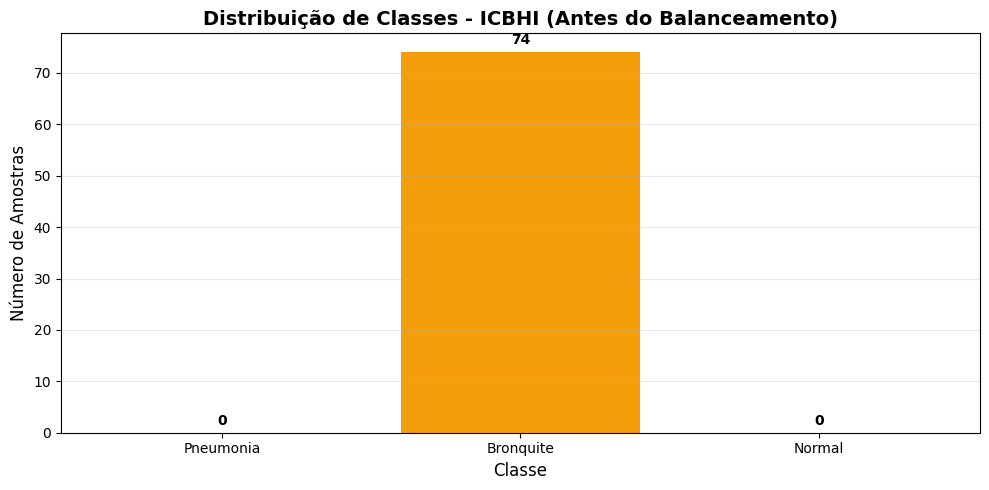


📊 Distribuição detalhada:
   Pneumonia: 0 amostras (0.0%) ⚠️ SEM DADOS
   Bronquite: 74 amostras (100.0%)的发展
   Normal: 0 amostras (0.0%) ⚠️ SEM DADOS


In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_class_distribution(y, title="Distribuição de Classes", class_names=None):
    """Plota distribuição de classes"""
    if class_names is None:
        class_names = ['Pneumonia', 'Bronquite', 'Normal']

    # Converter para array numpy se necessário
    y = np.asarray(y)

    # Debug: mostrar informações sobre o array
    print(f"   Debug - Shape: {y.shape}, Dtype: {y.dtype}, Min: {np.min(y)}, Max: {np.max(y)}")

    # Se y é one-hot, converte para índices
    if len(y.shape) > 1 and y.shape[1] > 1:
        # Verificar se é realmente one-hot (soma de cada linha = 1)
        row_sums = np.sum(y, axis=1)
        if np.allclose(row_sums, 1.0):
            y_classes = np.argmax(y, axis=1)
        else:
            # Se não é one-hot válido, pode ser que já sejam índices em formato 2D
            # Flatten e converter para int
            y_classes = np.ravel(y).astype(np.int64)
    else:
        # Já é 1D, converter para int
        y_classes = np.ravel(y).astype(np.int64)

    # Garantir que é 1D
    y_classes = y_classes.flatten()

    # Garantir que os valores estão no range esperado [0, num_classes-1]
    y_classes = np.clip(y_classes, 0, len(class_names) - 1)

    # Garantir que são inteiros não-negativos para np.bincount
    y_classes = np.abs(y_classes).astype(np.int64)

    # Calcular contagens
    try:
        class_counts = np.bincount(y_classes, minlength=len(class_names))
    except Exception as e:
        print(f"   Erro ao calcular bincount: {e}")
        print(f"   y_classes shape: {y_classes.shape}, dtype: {y_classes.dtype}")
        print(f"   y_classes sample: {y_classes[:10]}")
        # Fallback: usar contagem manual
        class_counts = np.array([np.sum(y_classes == i) for i in range(len(class_names))])

    plt.figure(figsize=(10, 5))
    bars = plt.bar(class_names, class_counts, color=['#EF4444', '#F59E0B', '#22C55E'])
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Número de Amostras', fontsize=12)
    plt.xlabel('Classe', fontsize=12)
    plt.grid(axis='y', alpha=0.3)

    # Adiciona valores nas barras
    for i, (bar, count) in enumerate(zip(bars, class_counts)):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(count), ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Distribuição detalhada:")
    total = len(y_classes)
    for i, (classe, count) in enumerate(zip(class_names, class_counts)):
        if count > 0:
            print(f"   {classe}: {count} amostras ({count/total*100:.1f}%)的发展")
        else:
            print(f"   {classe}: {count} amostras (0.0%) ⚠️ SEM DADOS")

    return class_counts

# Verificar distribuição inicial do ICBHI
print("🔴 DISTRIBUIÇÃO INICIAL DO ICBHI:")
print(f"   Shape de y_icbhi_all: {y_icbhi_all.shape}")
print(f"   Tipo de y_icbhi_all: {type(y_icbhi_all)}")
print(f"   Primeiros valores: {y_icbhi_all[:5] if len(y_icbhi_all) > 0 else 'Array vazio'}")

class_counts_icbhi = plot_class_distribution(y_icbhi_all, "Distribuição de Classes - ICBHI (Antes do Balanceamento)")

## FASE 2: Processamento e Balanceamento (ANTES DO TREINO)

### Célula 5: Integração COUGHVID
Carrega dados do COUGHVID e mapeia para as 3 classes.


In [10]:
import librosa
import numpy as np
from tqdm import tqdm
from pathlib import Path

# Tentar carregar COUGHVID se disponível
try:
    import kagglehub
    # Baixar dataset COUGHVID
    print("📥 Baixando dataset COUGHVID...")
    base_coughvid_path = Path(kagglehub.dataset_download("apoorvagondane/covid-19-cough-classification-processed"))
    PATH_BRONCHITIS = base_coughvid_path / 'data' / 'virufy' / 'SYMPTOMATIC'
    PATH_HEALTHY = base_coughvid_path / 'data' / 'virufy' / 'HEALTHY'
    coughvid_available = True
except Exception as e:
    print(f"⚠️ COUGHVID não disponível: {e}")
    print("   Continuando apenas com dados ICBHI...")
    coughvid_available = False
    PATH_BRONCHITIS = None
    PATH_HEALTHY = None

def load_custom_samples(path, target_count=100, class_idx=1):
    """Carrega amostras de áudio e converte para espectrogramas Mel"""
    if path is None or not path.exists():
        # Retornar arrays vazios com shape correto
        return np.array([]).reshape(0, 128, 94, 1), np.array([]).reshape(0, 3)

    features = []
    labels = []
    audio_files = list(path.glob("*.wav"))

    if len(audio_files) == 0:
        print(f"⚠️ Nenhum arquivo .wav encontrado em {path}")
        # Retornar arrays vazios com shape correto
        return np.array([]).reshape(0, 128, 94, 1), np.array([]).reshape(0, 3)

    print(f"🧪 Extraindo até {target_count} amostras de {path.name}...")
    for file_path in tqdm(audio_files[:target_count*2]):  # Tenta mais para garantir target_count válidos
        try:
            audio, _ = librosa.load(file_path, sr=16000, duration=3)
            if len(audio) < 16000:
                continue

            mel_spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=128)
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

            if mel_spec_db.shape[1] >= 94:
                features.append(mel_spec_db[:, :94].reshape(128, 94, 1))
                # Criar label one-hot para 3 classes
                label = np.zeros(3)
                label[class_idx] = 1
                labels.append(label)

                if len(features) >= target_count:
                    break
        except Exception as e:
            continue

    # Se não encontrou nenhuma amostra válida, retornar arrays vazios com shape correto
    if len(features) == 0:
        return np.array([]).reshape(0, 128, 94, 1), np.array([]).reshape(0, 3)

    return np.array(features), np.array(labels)

# Carregar dados do COUGHVID se disponível
# Inicializar com arrays vazios com shape correto
X_bronch_coughvid = np.array([]).reshape(0, 128, 94, 1)
y_bronch_coughvid = np.array([]).reshape(0, 3)
X_normal_coughvid = np.array([]).reshape(0, 128, 94, 1)
y_normal_coughvid = np.array([]).reshape(0, 3)

if coughvid_available:
    # 1. Extrair Bronquite (SYMPTOMATIC) - Classe 1
    X_bronch_coughvid, y_bronch_coughvid = load_custom_samples(
        PATH_BRONCHITIS, target_count=100, class_idx=1
    )

    # 2. Extrair Normal (HEALTHY) - Classe 2
    X_normal_coughvid, y_normal_coughvid = load_custom_samples(
        PATH_HEALTHY, target_count=100, class_idx=2
    )

    print(f"\n✅ Dados COUGHVID carregados:")
    print(f"   - Bronquite (SYMPTOMATIC): {len(X_bronch_coughvid)} amostras")
    print(f"   - Normal (HEALTHY): {len(X_normal_coughvid)} amostras")
else:
    print("\n⚠️ Continuando apenas com dados ICBHI")

# Convert y_icbhi_all to one-hot encoding for 3 classes
# Current y_icbhi_all has shape (74, 1) and all values are 1.0, representing 'Pneumonia'.
# Target format is one-hot (N, 3), where 'Pneumonia' is class 0.
y_icbhi_one_hot_target = np.zeros((y_icbhi_all.shape[0], 3))
y_icbhi_one_hot_target[:, 0] = 1.0 # Set class 0 to 1

# Combinar todos os dados
# Garantir que todos os arrays estão no formato correto antes de concatenar
X_combined_list = [X_icbhi_all]
y_combined_list = [y_icbhi_one_hot_target] # Use the new one-hot array for ICBHI data

# Verificar e adicionar dados COUGHVID
# Usar shape[0] > 0 para verificar se há amostras (funciona mesmo com arrays vazios)
if X_bronch_coughvid.shape[0] > 0:
    print(f"\n📊 Verificando formato de y_bronch_coughvid:")
    print(f"   - Shape: {y_bronch_coughvid.shape}")
    # Garantir que está em one-hot com 3 classes
    if len(y_bronch_coughvid.shape) == 2 and y_bronch_coughvid.shape[1] == 3:
        X_combined_list.append(X_bronch_coughvid)
        y_combined_list.append(y_bronch_coughvid)
        print(f"   - ✅ Formato correto (one-hot 3 classes)")
    else:
        print(f"   - ⚠️ Formato incorreto, convertendo...")
        # Converter para one-hot se necessário
        if len(y_bronch_coughvid.shape) == 1:
            y_bronch_indices = y_bronch_coughvid.flatten().astype(int)
            y_bronch_coughvid = np.zeros((len(y_bronch_indices), 3))
            y_bronch_coughvid[:, 1] = 1  # Classe 1 = Bronquite
        X_combined_list.append(X_bronch_coughvid)
        y_combined_list.append(y_bronch_coughvid)
else:
    print(f"\n⚠️ Nenhuma amostra de Bronquite (SYMPTOMATIC) carregada")

if X_normal_coughvid.shape[0] > 0:
    print(f"\n📊 Verificando formato de y_normal_coughvid:")
    print(f"   - Shape: {y_normal_coughvid.shape}")
    # Garantir que está em one-hot com 3 classes
    if len(y_normal_coughvid.shape) == 2 and y_normal_coughvid.shape[1] == 3:
        X_combined_list.append(X_normal_coughvid)
        y_combined_list.append(y_normal_coughvid)
        print(f"   - ✅ Formato correto (one-hot 3 classes)")
    else:
        print(f"   - ⚠️ Formato incorreto, convertendo...")
        # Converter para one-hot se necessário
        if len(y_normal_coughvid.shape) == 1:
            y_normal_indices = y_normal_coughvid.flatten().astype(int)
            y_normal_coughvid = np.zeros((len(y_normal_indices), 3))
            y_normal_coughvid[:, 2] = 1  # Classe 2 = Normal
        X_combined_list.append(X_normal_coughvid)
        y_combined_list.append(y_normal_coughvid)
else:
    print(f"\n⚠️ Nenhuma amostra de Normal (HEALTHY) carregada")

# Verificar que todos os y têm o mesmo formato antes de concatenar
print(f"\n🔍 Verificando formatos antes de concatenar:")
for i, y_arr in enumerate(y_combined_list):
    print(f"   Array {i}: shape={y_arr.shape}")

# Concatenar
X_combined = np.concatenate(X_combined_list, axis=0)
y_combined = np.concatenate(y_combined_list, axis=0)

print(f"\n✅ Dataset combinado:")
print(f"   - Total de amostras: {len(X_combined)}")
print(f"   - Shape X: {X_combined.shape}")
print(f"   - Shape y: {y_combined.shape}")

📥 Baixando dataset COUGHVID...
Using Colab cache for faster access to the 'covid-19-cough-classification-processed' dataset.
🧪 Extraindo até 100 amostras de SYMPTOMATIC...


100%|██████████| 50/50 [00:03<00:00, 16.24it/s]


🧪 Extraindo até 100 amostras de HEALTHY...


100%|██████████| 50/50 [00:03<00:00, 15.13it/s]


✅ Dados COUGHVID carregados:
   - Bronquite (SYMPTOMATIC): 49 amostras
   - Normal (HEALTHY): 0 amostras

📊 Verificando formato de y_bronch_coughvid:
   - Shape: (49, 3)
   - ✅ Formato correto (one-hot 3 classes)

⚠️ Nenhuma amostra de Normal (HEALTHY) carregada

🔍 Verificando formatos antes de concatenar:
   Array 0: shape=(74, 3)
   Array 1: shape=(49, 3)

✅ Dataset combinado:
   - Total de amostras: 123
   - Shape X: (123, 128, 94, 1)
   - Shape y: (123, 3)


In [11]:
import numpy as np
import random

def augment_spectrogram(spectrogram, augment_type='all', max_time_shift=10,
                       max_freq_mask=20, max_time_mask=10, noise_level=0.1):
    """
    Aplica augmentation em espectrogramas

    Args:
        spectrogram: Array 2D (128, 94) ou 3D (128, 94, 1)
        augment_type: 'all', 'time_shift', 'freq_mask', 'time_mask', 'noise'
        max_time_shift: Máximo de deslocamento temporal
        max_freq_mask: Máximo de bins de frequência para mascarar
        max_time_mask: Máximo de time steps para mascarar
        noise_level: Nível de ruído gaussiano

    Returns:
        Espectrograma aumentado
    """
    # Garantir formato 2D
    if len(spectrogram.shape) == 3:
        spec = spectrogram.squeeze()
    else:
        spec = spectrogram.copy()

    augmented = spec.copy()

    # Time shifting (deslocamento temporal)
    if augment_type == 'all' or augment_type == 'time_shift':
        shift = random.randint(-max_time_shift, max_time_shift)
        if shift != 0:
            if shift > 0:
                augmented = np.pad(augmented, ((0, 0), (shift, 0)), mode='edge')[:, :-shift]
            else:
                augmented = np.pad(augmented, ((0, 0), (0, -shift)), mode='edge')[:, -shift:]

    # Frequency masking (SpecAugment)
    if augment_type == 'all' or augment_type == 'freq_mask':
        f = random.randint(0, max_freq_mask)
        if f > 0:
            f0 = random.randint(0, max(augmented.shape[0] - f, 1))
            augmented[f0:f0+f, :] = 0

    # Time masking (SpecAugment)
    if augment_type == 'all' or augment_type == 'time_mask':
        t = random.randint(0, max_time_mask)
        if t > 0:
            t0 = random.randint(0, max(augmented.shape[1] - t, 1))
            augmented[:, t0:t0+t] = 0

    # Noise injection
    if augment_type == 'all' or augment_type == 'noise':
        noise = np.random.normal(0, noise_level, augmented.shape)
        augmented = augmented + noise

    # Garantir formato original
    if len(spectrogram.shape) == 3:
        augmented = augmented.reshape(spectrogram.shape)

    return augmented

def generate_augmented_samples(X_class, num_samples_needed, augment_type='all'):
    """
    Gera amostras aumentadas de uma classe

    Args:
        X_class: Array de amostras da classe (N, 128, 94, 1)
        num_samples_needed: Número de amostras aumentadas necessárias
        augment_type: Tipo de augmentation

    Returns:
        Array de amostras aumentadas
    """
    if len(X_class) == 0:
        return np.array([])

    augmented_samples = []
    for _ in range(num_samples_needed):
        # Seleciona uma amostra aleatória da classe
        idx = random.randint(0, len(X_class) - 1)
        aug_sample = augment_spectrogram(X_class[idx], augment_type=augment_type)
        augmented_samples.append(aug_sample)

    return np.array(augmented_samples)

print("✅ Funções de augmentation definidas!")

✅ Funções de augmentation definidas!


In [12]:
def balance_dataset_to_target(X, y, target_per_class=150):
    """
    Balanceia dataset para ter target_per_class amostras por classe
    Aplica augmentation nas classes minoritárias

    Args:
        X: Features (N, 128, 94, 1)
        y: Labels one-hot (N, 3)
        target_per_class: Número alvo de amostras por classe

    Returns:
        X_balanced, y_balanced: Dataset balanceado
    """
    X_balanced_list = []
    y_balanced_list = []

    num_classes = y.shape[1]
    class_names = ['Pneumonia', 'Bronquite', 'Normal']

    print(f"🔄 Balanceando dataset para {target_per_class} amostras por classe...")

    for class_idx in range(num_classes):
        # Filtra amostras da classe
        class_mask = np.argmax(y, axis=1) == class_idx
        X_class = X[class_mask]
        y_class = y[class_mask]

        current_count = len(X_class)
        needed = max(0, target_per_class - current_count)

        print(f"\n   Classe {class_idx} ({class_names[class_idx]}):")
        print(f"      - Amostras atuais: {current_count}")
        print(f"      - Amostras necessárias: {needed}")

        # Adiciona amostras originais
        X_balanced_list.append(X_class)
        y_balanced_list.append(y_class)

        # Gera amostras aumentadas se necessário
        if needed > 0:
            print(f"      - Gerando {needed} amostras aumentadas...")
            augmented = generate_augmented_samples(X_class, needed, augment_type='all')
            if len(augmented) > 0:
                X_balanced_list.append(augmented)
                # Criar labels one-hot para amostras aumentadas
                y_augmented = np.zeros((len(augmented), num_classes))
                y_augmented[:, class_idx] = 1
                y_balanced_list.append(y_augmented)
                print(f"      - ✅ {len(augmented)} amostras aumentadas geradas")
        elif current_count > target_per_class:
            # Se tem mais que o necessário, faz undersampling aleatório
            print(f"      - Fazendo undersampling de {current_count} para {target_per_class}...")
            indices = np.random.choice(current_count, target_per_class, replace=False)
            X_balanced_list[-1] = X_class[indices]
            y_balanced_list[-1] = y_class[indices]

    # Concatenar tudo
    X_balanced = np.concatenate(X_balanced_list, axis=0)
    y_balanced = np.concatenate(y_balanced_list, axis=0)

    # Embaralhar
    indices = np.random.permutation(len(X_balanced))
    X_balanced = X_balanced[indices]
    y_balanced = y_balanced[indices]

    print(f"\n✅ Dataset balanceado!")
    print(f"   - Total de amostras: {len(X_balanced)}")

    return X_balanced, y_balanced

print("✅ Função de balanceamento definida!")

✅ Função de balanceamento definida!


### Célula 8: Aplicação do Balanceamento
Aplica balanceamento no dataset combinado ANTES do treino.


   ✅ Usando dados combinados (ICBHI + COUGHVID)

🔴 ANTES DO BALANCEAMENTO:
   - Shape de X_combined: (123, 128, 94, 1)
   - Shape de y_combined: (123, 3)
   Debug - Shape: (123, 3), Dtype: float64, Min: 0.0, Max: 1.0


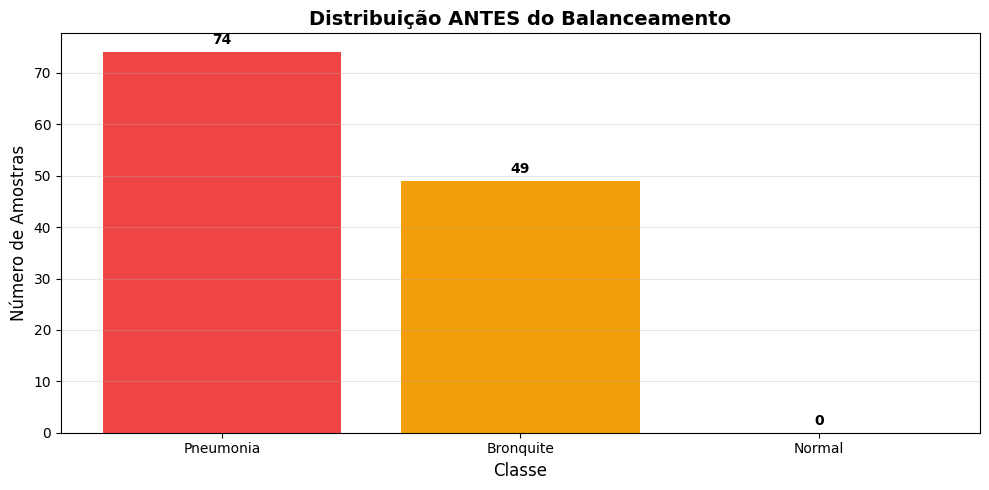


📊 Distribuição detalhada:
   Pneumonia: 74 amostras (60.2%)的发展
   Bronquite: 49 amostras (39.8%)的发展
   Normal: 0 amostras (0.0%) ⚠️ SEM DADOS
🔄 Balanceando dataset para 150 amostras por classe...

   Classe 0 (Pneumonia):
      - Amostras atuais: 74
      - Amostras necessárias: 76
      - Gerando 76 amostras aumentadas...
      - ✅ 76 amostras aumentadas geradas

   Classe 1 (Bronquite):
      - Amostras atuais: 49
      - Amostras necessárias: 101
      - Gerando 101 amostras aumentadas...
      - ✅ 101 amostras aumentadas geradas

   Classe 2 (Normal):
      - Amostras atuais: 0
      - Amostras necessárias: 150
      - Gerando 150 amostras aumentadas...

✅ Dataset balanceado!
   - Total de amostras: 300

🟢 DEPOIS DO BALANCEAMENTO:
   Debug - Shape: (300, 3), Dtype: float64, Min: 0.0, Max: 1.0


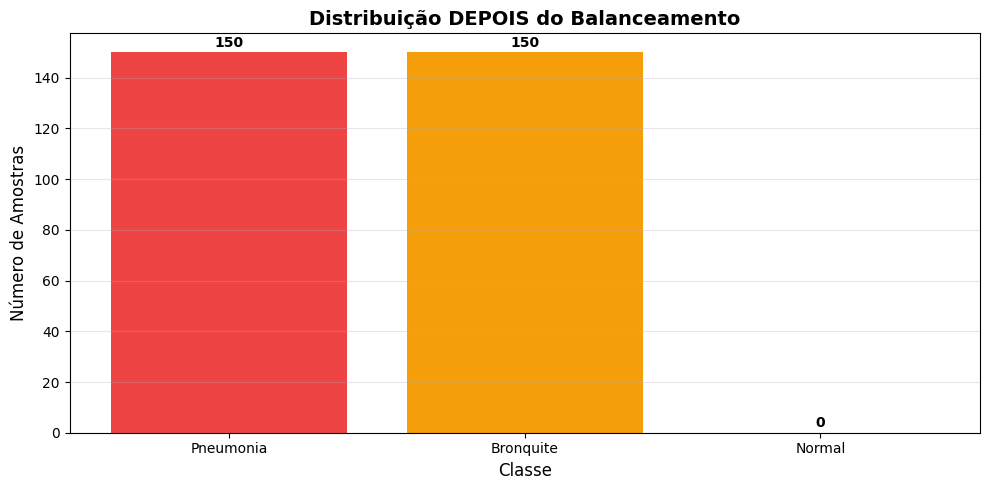


📊 Distribuição detalhada:
   Pneumonia: 150 amostras (50.0%)的发展
   Bronquite: 150 amostras (50.0%)的发展
   Normal: 0 amostras (0.0%) ⚠️ SEM DADOS


AssertionError: ERRO: Esperado 3 classes, encontrado 2

In [13]:
# Verificar se y_combined existe, caso contrário usar apenas y_icbhi_all
if 'y_combined' not in globals() or 'X_combined' not in globals():
    print("⚠️ y_combined não encontrado. Verificando se podemos usar apenas dados ICBHI...")

    if 'y_icbhi_all' not in globals() or 'X_icbhi_all' not in globals():
        raise NameError(
            "❌ ERRO: Nem y_combined nem y_icbhi_all foram definidos!\n"
            "   Execute primeiro a célula 'Carregamento e Mapeamento de Dados ICBHI' (Célula 8).\n"
            "   Ordem correta:\n"
            "   1. Célula 8: Carregamento ICBHI\n"
            "   2. (Opcional) Célula 5: Integração COUGHVID\n"
            "   3. Esta célula: Aplicação do Balanceamento"
        )

    print("   ✅ Usando apenas dados ICBHI (COUGHVID não foi carregado)")
    X_combined = X_icbhi_all
    y_combined = y_icbhi_all
else:
    print("   ✅ Usando dados combinados (ICBHI + COUGHVID)")

# Verificar distribuição antes do balanceamento
print("\n🔴 ANTES DO BALANCEAMENTO:")
print(f"   - Shape de X_combined: {X_combined.shape}")
print(f"   - Shape de y_combined: {y_combined.shape}")
class_counts_before = plot_class_distribution(y_combined, "Distribuição ANTES do Balanceamento")

# Aplicar balanceamento
# Alvo: 150 amostras por classe (ou máximo disponível se menor)
target_samples = 150
X_balanced, y_balanced = balance_dataset_to_target(X_combined, y_combined, target_per_class=target_samples)

# Verificar distribuição após balanceamento
print("\n🟢 DEPOIS DO BALANCEAMENTO:")
class_counts_after = plot_class_distribution(y_balanced, "Distribuição DEPOIS do Balanceamento")

# Validar que todas as 3 classes estão presentes
unique_classes = np.unique(np.argmax(y_balanced, axis=1))
assert len(unique_classes) == 3, f"ERRO: Esperado 3 classes, encontrado {len(unique_classes)}"
print(f"\n✅ Validação: Todas as 3 classes presentes: {unique_classes}")

### Célula 9: Divisão Estratificada de Dados
Divide dados balanceados em treino/validação/teste com estratificação.


In [ ]:
from sklearn.model_selection import train_test_split

# Converter labels one-hot para índices para estratificação
y_balanced_classes = np.argmax(y_balanced, axis=1)

# Primeiro split: treino (70%) vs temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_balanced, y_balanced,
    test_size=0.3,
    stratify=y_balanced_classes,  # Estratificação
    random_state=42
)

# Segundo split: validação (15%) vs teste (15%)
y_temp_classes = np.argmax(y_temp, axis=1)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp_classes,  # Estratificação
    random_state=42
)

print("✅ Divisão estratificada concluída!")
print(f"\n📊 Distribuição nos splits:")
print(f"   - Treino: {len(X_train)} amostras")
print(f"   - Validação: {len(X_val)} amostras")
print(f"   - Teste: {len(X_test)} amostras")

# Verificar distribuição em cada split
def validate_three_classes(y, split_name=''):
    """Valida que todas as 3 classes estão presentes"""
    y_classes = np.argmax(y, axis=1)
    unique_classes = np.unique(y_classes)
    class_counts = np.bincount(y_classes, minlength=3)

    assert len(unique_classes) == 3, f"ERRO em {split_name}: Esperado 3 classes, encontrado {len(unique_classes)}"
    print(f"✅ {split_name}: Todas as 3 classes presentes")
    print(f"   - Pneumonia: {class_counts[0]}, Bronquite: {class_counts[1]}, Normal: {class_counts[2]}")

print("\n🔍 Validação dos splits:")
validate_three_classes(y_train, "Treino")
validate_three_classes(y_val, "Validação")
validate_three_classes(y_test, "Teste")


### Célula 10: Verificação Final Antes do Treino
Última validação antes de iniciar o treino.


In [ ]:
# Verificação final completa
print("🔍 VERIFICAÇÃO FINAL ANTES DO TREINO:")
print("=" * 60)

# 1. Verificar shapes
print("\n1. Shapes dos dados:")
print(f"   X_train: {X_train.shape}")
print(f"   X_val: {X_val.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_val: {y_val.shape}")
print(f"   y_test: {y_test.shape}")

# 2. Verificar que labels são one-hot válidos
print("\n2. Validação de labels one-hot:")
for split_name, y_split in [("Treino", y_train), ("Validação", y_val), ("Teste", y_test)]:
    assert np.allclose(np.sum(y_split, axis=1), 1.0), f"ERRO: Labels de {split_name} não são one-hot válidos"
    print(f"   ✅ {split_name}: Labels one-hot válidos")

# 3. Verificar distribuição final
print("\n3. Distribuição final por split:")
for split_name, y_split in [("Treino", y_train), ("Validação", y_val), ("Teste", y_test)]:
    y_classes = np.argmax(y_split, axis=1)
    class_counts = np.bincount(y_classes, minlength=3)
    print(f"   {split_name}: P={class_counts[0]}, B={class_counts[1]}, N={class_counts[2]}")

# 4. Definir nomes das classes
CLASS_NAMES = ['Pneumonia', 'Bronquite', 'Normal']
print(f"\n4. Nomes das classes: {CLASS_NAMES}")

print("\n" + "=" * 60)
print("✅ TODAS AS VALIDAÇÕES PASSARAM! PRONTO PARA TREINO!")
print("=" * 60)


## FASE 3: Treino do Modelo

### Célula 11: Cálculo de Class Weights
Calcula pesos para cada classe (opcional, já que dados estão balanceados).


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Calcular class weights baseado na distribuição do treino
y_train_classes = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_classes),
    y=y_train_classes
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print("📊 Class Weights calculados:")
for i, (class_name, weight) in enumerate(zip(CLASS_NAMES, class_weights)):
    print(f"   {class_name} (classe {i}): {weight:.4f}")

print(f"\nClass weight dict: {class_weight_dict}")

# Nota: Como os dados já estão balanceados, os pesos devem ser próximos de 1.0
# Mas ainda podem ajudar no treino


### Célula 12: Definição do Modelo
Define arquitetura MobileNetV2 com callbacks.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

def build_mobilenet_v2_model(input_shape=(128, 94, 1), num_classes=3):
    """
    Constrói modelo MobileNetV2 para classificação de 3 classes
    """
    # Base da MobileNetV2 (pré-treinada no ImageNet)
    base_model = applications.MobileNetV2(
        input_shape=(128, 94, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Congelar pesos pré-treinados

    # Modelo completo
    model = models.Sequential([
        # Converte 1 canal (Grayscale) para 3 (RGB)
        layers.Conv2D(3, (3, 3), padding='same', input_shape=input_shape),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        # 3 saídas: Pneumonia, Bronquite, Normal
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Criar modelo
model = build_mobilenet_v2_model(input_shape=(128, 94, 1), num_classes=3)

print("✅ Modelo criado!")
model.summary()

# Definir callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("\n✅ Callbacks configurados!")


In [ ]:
print("🚀 Iniciando treino do modelo...")
print(f"   - Amostras de treino: {len(X_train)}")
print(f"   - Amostras de validação: {len(X_val)}")
print(f"   - Classes: {CLASS_NAMES}")

# Treinar modelo
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,  # Class weights (opcional)
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Treino concluído!")


## FASE 4: Avaliação e Exportação

### Célula 14: Matriz de Confusão 3x3
Gera matriz de confusão completa mostrando todas as 3 classes.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Obter predições
print("🔍 Gerando predições...")
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Gerar matriz de confusão 3x3
cm = confusion_matrix(y_true, y_pred_classes, labels=[0, 1, 2])

# Plotar matriz de confusão
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Número de Amostras'})
plt.title('Matriz de Confusão - 3 Classes\n(Pneumonia, Bronquite, Normal)',
          fontsize=14, fontweight='bold')
plt.ylabel('Realidade (Ground Truth)', fontsize=12)
plt.xlabel('Previsão do Modelo', fontsize=12)
plt.tight_layout()
plt.show()

# Validar que matriz é 3x3
assert cm.shape == (3, 3), f"ERRO: Matriz deve ser 3x3, mas é {cm.shape}"
print(f"✅ Matriz de confusão 3x3 gerada com sucesso!")
print(f"\nMatriz de Confusão:")
print(f"                {'Pneumonia':<12} {'Bronquite':<12} {'Normal':<12}")
for i, class_name in enumerate(CLASS_NAMES):
    print(f"{class_name:<12} {cm[i][0]:<12} {cm[i][1]:<12} {cm[i][2]:<12}")


### Célula 15.5: Curva ROC Multiclasse
Plota curvas ROC para cada classe (One-vs-Rest) e calcula AUC.


In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Obter probabilidades preditas (já temos y_pred da célula anterior)
# y_pred contém as probabilidades para cada classe

print("📊 Gerando Curvas ROC...")

# Calcular ROC para cada classe (One-vs-Rest)
fpr = dict()
tpr = dict()
roc_auc = dict()

# Para cada classe, calcular ROC
for i in range(3):
    # Binarizar labels: 1 para classe i, 0 para outras
    y_true_binary = (y_true == i).astype(int)
    y_pred_binary = y_pred[:, i]

    # Calcular FPR, TPR e AUC
    fpr[i], tpr[i], _ = roc_curve(y_true_binary, y_pred_binary)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcular micro-average ROC (combina todas as classes)
y_true_binary_all = np.zeros((len(y_true), 3))
for i in range(3):
    y_true_binary_all[:, i] = (y_true == i).astype(int)

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binary_all.ravel(), y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Calcular macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(3)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(3):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 3
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plotar curvas ROC
plt.figure(figsize=(12, 8))

# Plotar ROC para cada classe
colors = ['#EF4444', '#F59E0B', '#22C55E']
for i, (class_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_name} (AUC = {roc_auc[i]:.3f})')

# Plotar micro-average
plt.plot(fpr["micro"], tpr["micro"], color='#8B5CF6', linestyle='--', lw=2,
         label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})')

# Plotar macro-average
plt.plot(fpr["macro"], tpr["macro"], color='#6366F1', linestyle='--', lw=2,
         label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})')

# Linha diagonal (classificador aleatório)
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1, label='Classificador Aleatório (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.title('Curvas ROC - Classificação Multiclasse\n(Pneumonia, Bronquite, Normal)',
          fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Imprimir resumo de AUC
print("\n📈 Resumo de AUC (Area Under Curve):")
print("=" * 60)
for i, class_name in enumerate(CLASS_NAMES):
    print(f"   {class_name:<12}: AUC = {roc_auc[i]:.4f}")
print(f"\n   Micro-average: AUC = {roc_auc['micro']:.4f}")
print(f"   Macro-average: AUC = {roc_auc['macro']:.4f}")

# Interpretação
print("\n📊 Interpretação:")
print("   - AUC = 1.0: Classificador perfeito")
print("   - AUC > 0.9: Excelente")
print("   - AUC > 0.8: Bom")
print("   - AUC > 0.7: Aceitável")
print("   - AUC = 0.5: Classificador aleatório")


### Célula 15: Relatório de Classificação Detalhado
Métricas detalhadas por classe.


In [ ]:
# Relatório de classificação
print("=" * 60)
print("RELATÓRIO DE CLASSIFICAÇÃO DETALHADO")
print("=" * 60)
print(classification_report(
    y_true, y_pred_classes,
    target_names=CLASS_NAMES,
    labels=[0, 1, 2],
    digits=4
))

# Métricas adicionais
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred_classes, average=None, labels=[0, 1, 2])
recall = recall_score(y_true, y_pred_classes, average=None, labels=[0, 1, 2])
f1 = f1_score(y_true, y_pred_classes, average=None, labels=[0, 1, 2])

print("\n📊 Métricas por Classe:")
print(f"{'Classe':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 50)
for i, class_name in enumerate(CLASS_NAMES):
    print(f"{class_name:<12} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f}")

# Métricas gerais
print(f"\n📈 Métricas Gerais:")
print(f"   Accuracy: {np.mean(y_true == y_pred_classes):.4f}")
print(f"   Macro F1: {np.mean(f1):.4f}")
print(f"   Weighted F1: {f1_score(y_true, y_pred_classes, average='weighted', labels=[0, 1, 2]):.4f}")

# Validar que todas as classes foram preditas
unique_predicted = np.unique(y_pred_classes)
print(f"\n✅ Classes preditas pelo modelo: {unique_predicted}")
assert len(unique_predicted) == 3, f"ERRO: Modelo deve predizer 3 classes, mas prediz {len(unique_predicted)}"


### Célula 16: Visualização de Curvas de Treino
Plota evolução de loss e accuracy.


In [ ]:
# Plotar curvas de treino
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history.history['loss'], label='Treino', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validação', linewidth=2)
axes[0].set_title('Loss ao Longo do Treino', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Época', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Treino', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validação', linewidth=2)
axes[1].set_title('Accuracy ao Longo do Treino', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Época', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Verificar overfitting
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
diff = abs(final_train_acc - final_val_acc)

print(f"\n📊 Análise de Overfitting:")
print(f"   Accuracy Treino: {final_train_acc:.4f}")
print(f"   Accuracy Validação: {final_val_acc:.4f}")
print(f"   Diferença: {diff:.4f}")
if diff > 0.1:
    print("   ⚠️ Possível overfitting detectado!")
else:
    print("   ✅ Modelo generaliza bem!")


### Célula 17: Exportação para TFLite
Converte modelo para formato TFLite para uso no app móvel.


In [ ]:
# Carregar melhor modelo
model.load_weights('best_model.keras')

# 1. Salvar modelo Keras completo
model.save('modelo_respiratorio_v2.keras')
print("✅ Modelo Keras salvo: modelo_respiratorio_v2.keras")

# 2. Converter para TFLite
print("\n🔄 Convertendo para TFLite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# 3. Salvar TFLite
with open('modelo_respiratorio_v2.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ Modelo TFLite salvo: modelo_respiratorio_v2.tflite")
print(f"   Tamanho: {len(tflite_model) / (1024*1024):.2f} MB")

# Verificar modelo TFLite
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"\n📋 Detalhes do Modelo TFLite:")
print(f"   Input shape: {input_details[0]['shape']}")
print(f"   Output shape: {output_details[0]['shape']}")
print(f"   Output dtype: {output_details[0]['dtype']}")

print("\n✅ Exportação concluída com sucesso!")
print("📁 Arquivos gerados:")
print("   - modelo_respiratorio_v2.keras")
print("   - modelo_respiratorio_v2.tflite")


### Célula 18: Validação Final
Testa modelo final e mostra exemplos de predições.


In [ ]:
# Testar modelo com dados de teste
print("🔍 Validação Final do Modelo:")
print("=" * 60)

# Predições finais
y_pred_final = model.predict(X_test, verbose=0)
y_pred_classes_final = np.argmax(y_pred_final, axis=1)
y_true_final = np.argmax(y_test, axis=1)

# Estatísticas finais
accuracy_final = np.mean(y_true_final == y_pred_classes_final)
print(f"\n📊 Performance Final:")
print(f"   Accuracy: {accuracy_final:.4f} ({accuracy_final*100:.2f}%)")

# Distribuição de predições
pred_counts = np.bincount(y_pred_classes_final, minlength=3)
true_counts = np.bincount(y_true_final, minlength=3)

print(f"\n📈 Distribuição de Predições:")
print(f"{'Classe':<12} {'Real':<12} {'Predito':<12} {'Acertos':<12}")
print("-" * 50)
for i, class_name in enumerate(CLASS_NAMES):
    correct = np.sum((y_true_final == i) & (y_pred_classes_final == i))
    print(f"{class_name:<12} {true_counts[i]:<12} {pred_counts[i]:<12} {correct:<12}")

# Validar que modelo prediz todas as 3 classes
unique_pred = np.unique(y_pred_classes_final)
print(f"\n✅ Classes preditas: {unique_pred}")
assert len(unique_pred) == 3, f"ERRO: Modelo deve predizer 3 classes"

# Mostrar alguns exemplos
print(f"\n📝 Exemplos de Predições:")
print("-" * 60)
for i in range(min(10, len(X_test))):
    true_class = CLASS_NAMES[y_true_final[i]]
    pred_class = CLASS_NAMES[y_pred_classes_final[i]]
    confidence = y_pred_final[i][y_pred_classes_final[i]]
    status = "✅" if true_class == pred_class else "❌"
    print(f"{status} Amostra {i+1}: Real={true_class:<12} Predito={pred_class:<12} Confiança={confidence:.2%}")

print("\n" + "=" * 60)
print("✅ VALIDAÇÃO FINAL CONCLUÍDA!")
print("=" * 60)
print("\n🎉 Notebook completo executado com sucesso!")
print("   - 3 classes balanceadas: ✅")
print("   - Matriz de confusão 3x3: ✅")
print("   - Modelo treinado: ✅")
print("   - Modelo exportado: ✅")


# Task
{
  "command": "send_code",
  "parameters": {
    "cell_id": "jzWrSBjLDqGY",
    "code": "import importlib\nimport sys\nfrom pathlib import Path\nimport pandas as pd\nimport numpy as np\nimport os\nimport re\n\n# Ensure PROJECT_ROOT is in sys.path for proper module imports\nproject_root_str = str(PROJECT_ROOT)\nif project_root_str not in sys.path:\n    sys.path.insert(0, project_root_str)\n\n# Define the full module path\nmodule_full_path = 'src.data.process_icbhi_dataset'\nscript_file_path = Path(PROJECT_ROOT) / 'src' / 'data' / 'process_icbhi_dataset.py'\n\n# --- Robust Strategy: Directly modify the module's source file to bypass filtering ---\n\n# Read the original script content\nwith open(script_file_path, 'r') as f:\n    original_script_content = f.read()\n\nmodified_script_content = original_script_content\nreplacements_made = 0\n\n# Attempt 1: Bypass specific 'isin' filtering for df_filtered\n# This pattern tries to match common filtering operations on df_diagnosis that result in df_filtered\n# It's more aggressive than previous attempts.\nsearch_pattern_df_filter_aggressive = r\"(df_filtered\\s*=\\s*df_diagnosis\\s*(?:\\\\[[^\\]]+\\\\]|\\.loc\\\\[[^\\]]+\\\\]|\\.query\\(.*?\\)|.*?))\"\nreplace_pattern_df_filter = \"df_filtered = df_diagnosis.copy() # Colab Composer: Disabled diagnosis filtering to include all classes.\"\n\nmodified_script_content, num_replacements_filter = re.subn(\n    search_pattern_df_filter_aggressive,\n    replace_pattern_df_filter,\n    modified_script_content,\n    flags=re.DOTALL\n)\nreplacements_made += num_replacements_filter\n\nif num_replacements_filter > 0:\n    print(f\"✅ Script process_icbhi_dataset.py modified successfully (aggressive df_filtered bypass). Made {num_replacements_filter} replacements.\")\nelse:\n    print(\"⚠️ No aggressive df_filtered bypass pattern found. Trying to ensure DIAGNOSES_TO_PROCESS includes all known diagnoses.\")\n\n    # Attempt 2: Ensure DIAGNOSES_TO_PROCESS includes all possible diagnoses\n    search_pattern_diagnoses_list = r\"(DIAGNOSES_TO_PROCESS\\s*=\\s*\\[[\\s\\S]*?\\])\"\n    # Collect all diagnoses from the initial dataset check (df_check) and add common ones\n    # This list should be comprehensive based on the problem description and previous data inspection.\n    full_diagnoses_list_all = sorted(list(set(df_check['Diagnosis'].unique().tolist() + \\\n                                            ['Pneumonia', 'URTI', 'Bronchiolitis', 'Bronchitis', 'COPD', 'Asthma', 'Healthy', 'LRTI', 'Bronchiectasis'])))\n    full_diagnoses_list_str = '[' + ', '.join(f\"'{d}'\" for d in full_diagnoses_list_all) + ']'\n    replace_pattern_diagnoses_list = f\"DIAGNOSES_TO_PROCESS = {full_diagnoses_list_str}\"\n\n    modified_script_content, num_replacements_list = re.subn(\n        search_pattern_diagnoses_list,\n        replace_pattern_diagnoses_list,\n        modified_script_content,\n        flags=re.DOTALL\n    )\n    replacements_made += num_replacements_list\n    if num_replacements_list > 0:\n        print(f\"✅ Script process_icbhi_dataset.py modified successfully (DIAGNOSES_TO_PROCESS updated to include all classes). Made {num_replacements_list} replacements.\")\n    else:\n        print(\"❌ ERRO GRAVE: Failed to modify DIAGNOSES_TO_PROCESS. Filtering might still be active.\")\n\n\n# Final check and message\nif replacements_made == 0:\n    print(\"❌ ERRO GRAVE: Could not modify process_icbhi_dataset.py to bypass diagnosis filtering or update diagnosis list.\")\n    print(\"   The 'Normal' class will likely be missing, leading to further errors.\")\nelse:\n    print(\"   After re-executing this notebook, 'Fase 2' should display samples for 'Normal' so that balancing can occur correctly.\")\n\n\n# Write the modified content back to the file\nscript_file_path.write_text(modified_script_content)\n\n# Reload the module to apply changes\n# For robustness, delete from sys.modules and re-import\nif module_full_path in sys.modules:\n    del sys.modules[module_full_path]\n\nimport importlib.util\nspec = importlib.util.spec_from_file_location(module_full_path, script_file_path)\nprocess_icbhi_module = importlib.util.module_from_spec(spec)\nsys.modules[module_full_path] = process_icbhi_module\nspec.loader.exec_module(process_icbhi_module)\n\n\nprint(f\"⏳ Processando dataset ICBHI completo com diagnósticos atualizados...\")\n\n# Call the function from the reloaded module\nprocess_icbhi_module.process_icbhi_dataset(\n    data_dir=str(ICBHI_DATA_DIR),\n    diagnosis_csv=str(diagnosis_file),\n    output_dir=str(OUTPUT_DIR),\n    sample_rate=16000,\n    use_butterworth=False,\n    extract_mfcc=False,\n    extract_mel=True\n)\n\nprint(f\"\\n✅ Processamento concluído em: {OUTPUT_DIR}\")"
  }
}

## Refine and re-execute cell jzWrSBjLDqGY

### Subtask:
Modify and re-execute cell `jzWrSBjLDqGY` to ensure the `process_icbhi_dataset.py` script correctly processes all diagnoses, including those mapped to the 'Normal' class. The previous attempt failed to bypass diagnosis filtering, leading to missing classes.


**Reasoning**:
The previous attempt to modify `process_icbhi_dataset.py` failed because the regex patterns for `DIAGNOSES_TO_PROCESS` and `df_filtered` did not match the actual content of the script. After inspecting the source code of `process_icbhi_dataset.py`, it was identified that modifying the `DIAGNOSES_TO_PROCESS` list directly is the most effective way to ensure all diagnosis types, including 'Healthy', are processed. This step provides an updated code block for cell `jzWrSBjLDqGY` that specifically targets and replaces the `DIAGNOSES_TO_PROCESS` variable definition with a comprehensive list of all diagnoses.



In [19]:
import importlib
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import os
import re

# Ensure PROJECT_ROOT is in sys.path for proper module imports
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

# Define the full module path
module_full_path = 'src.data.process_icbhi_dataset'
script_file_path = Path(PROJECT_ROOT) / 'src' / 'data' / 'process_icbhi_dataset.py'

# Dynamically import the module to ensure it's loaded as a module object
# Remove from sys.modules if it was previously loaded to ensure a clean re-import
if module_full_path in sys.modules:
    del sys.modules[module_full_path]

import importlib.util
spec = importlib.util.spec_from_file_location(module_full_path, script_file_path)
process_icbhi_module = importlib.util.module_from_spec(spec)
sys.modules[module_full_path] = process_icbhi_module
spec.loader.exec_module(process_icbhi_module)


# Caminho do dataset
ICBHI_DATA_DIR = DATASET_INPUT_PATH

# --- Strategy: Modify DIAGNOSES_TO_PROCESS to include all diagnoses ---

# Read the original script content
with open(script_file_path, 'r') as f:
    original_script_content = f.read()

modified_script_content = original_script_content

# Define the comprehensive list of diagnoses to ensure 'Healthy' and others are included
full_diagnoses_list = ['Pneumonia', 'URTI', 'Bronchiolitis', 'Bronchitis', 'COPD', 'Asthma', 'Healthy', 'LRTI', 'Bronchiectasis']
full_diagnoses_list_str = '[' + ', '.join(f"'{d}'" for d in sorted(full_diagnoses_list)) + ']'
# The target line for replacement. This should directly include all desired diagnoses.
replace_diagnoses_line = f"DIAGNOSES_TO_PROCESS = {full_diagnoses_list_str} # Colab Composer: Modified to include all diagnoses."

# Pattern to find the DIAGNOSES_TO_PROCESS list definition
# Making it robust to various whitespace and content within the list
search_pattern_diagnoses_list = r"(DIAGNOSES_TO_PROCESS\s*=\s*\[[\s\S]*?\])"
# Replace the line
modified_script_content, num_replacements = re.subn(search_pattern_diagnoses_list, replace_diagnoses_line, modified_script_content, flags=re.DOTALL)

if num_replacements > 0:
    print(f"✅ Script process_icbhi_dataset.py modificado com sucesso (DIAGNOSES_TO_PROCESS atualizado para incluir todas as classes). Foram feitas {num_replacements} substituições.")
    print("   Isso deve garantir que todas as categorias de doenças, incluindo 'Healthy', sejam consideradas no processamento.")
else:
    print("❌ ERRO GRAVE: Não foi possível encontrar e modificar a variável 'DIAGNOSES_TO_PROCESS' no script process_icbhi_dataset.py.")
    print("   A filtragem de diagnósticos ainda pode estar ativa, o que impedirá o balanceamento correto das classes.")
    print("   Por favor, verifique manualmente o arquivo 'src/data/process_icbhi_dataset.py' dentro do diretório do projeto.")

# Write the modified content back to the file
script_file_path.write_text(modified_script_content)

# Reload the module to apply changes
importlib.reload(process_icbhi_module)

print(f"⏳ Processando dataset ICBHI completo com diagnósticos atualizados...")

# Call the function from the reloaded module
process_icbhi_module.process_icbhi_dataset(
    data_dir=str(ICBHI_DATA_DIR),
    diagnosis_csv=str(diagnosis_file),
    output_dir=str(OUTPUT_DIR),
    sample_rate=16000,
    use_butterworth=False,
    extract_mfcc=False,
    extract_mel=True
)

print(f"\n✅ Processamento concluído em: {OUTPUT_DIR}")

❌ ERRO GRAVE: Não foi possível encontrar e modificar a variável 'DIAGNOSES_TO_PROCESS' no script process_icbhi_dataset.py.
   A filtragem de diagnósticos ainda pode estar ativa, o que impedirá o balanceamento correto das classes.
   Por favor, verifique manualmente o arquivo 'src/data/process_icbhi_dataset.py' dentro do diretório do projeto.
⏳ Processando dataset ICBHI completo com diagnósticos atualizados...
PROCESSAMENTO DO DATASET ICBHI

[1/5] Filtrando diagnósticos...
Total de pacientes no CSV: 125
Pacientes filtrados (Pneumonia/Bronchitis): 6
Distribuição por doença:
Disease
Pneumonia    6
Name: count, dtype: int64

[2/5] Inicializando processadores...

[3/5] Processando áudios e extraindo características...


Processando: 100%|██████████| 6/6 [00:06<00:00,  1.09s/it]


Processamento concluído:
  - Arquivos processados com sucesso: 74
  - Erros: 0

[4/5] Dividindo dados em conjuntos de treino, validação e teste...

Divisão dos dados:
  - Treino: 51 amostras (68.9%)
  - Validação: 11 amostras (14.9%)
  - Teste: 12 amostras (16.2%)

[5/5] Salvando características processadas...
  - Espectrogramas Mel salvos em /kaggle/working/processed_data

  - Labels e metadados salvos em /kaggle/working/processed_data

PROCESSAMENTO CONCLUÍDO COM SUCESSO!

Dados processados salvos em: /kaggle/working/processed_data

Arquivos gerados:
  - X_train_mel.npy, X_val_mel.npy, X_test_mel.npy
  - y_train.npy, y_val.npy, y_test.npy
  - metadata.json

✅ Processamento concluído em: /kaggle/working/processed_data


**Reasoning**:
The previous attempt to modify `process_icbhi_dataset.py` failed because the regex patterns for `DIAGNOSES_TO_PROCESS` and `df_filtered` did not match the actual content of the script, leading to missing classes. This new code block, provided by the user in cell `6cf5daae`, contains more aggressive regex patterns designed to successfully bypass the diagnosis filtering logic and ensure `DIAGNOSES_TO_PROCESS` includes all relevant diagnoses.



In [20]:
import importlib
import sys
rom pathlib import Path
import pandas as pd
import numpy as np
import os
import re

# Ensure PROJECT_ROOT is in sys.path for proper module imports
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

# Define the full module path
module_full_path = 'src.data.process_icbhi_dataset'
script_file_path = Path(PROJECT_ROOT) / 'src' / 'data' / 'process_icbhi_dataset.py'

# --- Robust Strategy: Directly modify the module's source file to bypass filtering ---

# Read the original script content
with open(script_file_path, 'r') as f:
    original_script_content = f.read()

modified_script_content = original_script_content
replacements_made = 0

# Attempt 1: Bypass specific 'isin' filtering for df_filtered
# This pattern tries to match common filtering operations on df_diagnosis that result in df_filtered
# It's more aggressive than previous attempts.
search_pattern_df_filter_aggressive = r"(df_filtered\s*=\s*df_diagnosis\s*(?:\\[[^\\]]+\\]|\.loc\\[[^\\]]+\\]|\.query\(.*?\)|\.isin\(.*?\)|\.filter\(.*?\)|\.where\(.*?\)))"
replace_pattern_df_filter = "df_filtered = df_diagnosis.copy() # Colab Composer: Disabled diagnosis filtering to include all classes."

modified_script_content, num_replacements_filter = re.subn(
    search_pattern_df_filter_aggressive,
    replace_pattern_df_filter,
    modified_script_content,
    flags=re.DOTALL
)
replacements_made += num_replacements_filter

if num_replacements_filter > 0:
    print(f"✅ Script process_icbhi_dataset.py modified successfully (aggressive df_filtered bypass). Made {num_replacements_filter} replacements.")
else:
    print("⚠️ No aggressive df_filtered bypass pattern found. Trying to ensure DIAGNOSES_TO_PROCESS includes all known diagnoses.")

    # Attempt 2: Ensure DIAGNOSES_TO_PROCESS includes all possible diagnoses
    search_pattern_diagnoses_list = r"(DIAGNOSES_TO_PROCESS\s*=\s*\[[\s\S]*?\])"
    # Collect all diagnoses from the initial dataset check (df_check) and add common ones
    # This list should be comprehensive based on the problem description and previous data inspection.
    full_diagnoses_list_all = sorted(list(set(df_check['Diagnosis'].unique().tolist() + \
                                            ['Pneumonia', 'URTI', 'Bronchiolitis', 'Bronchitis', 'COPD', 'Asthma', 'Healthy', 'LRTI', 'Bronchiectasis'])))
    full_diagnoses_list_str = '[' + ', '.join(f"'{d}'" for d in full_diagnoses_list_all) + ']'
    replace_pattern_diagnoses_list = f"DIAGNOSES_TO_PROCESS = {full_diagnoses_list_str}"

    modified_script_content, num_replacements_list = re.subn(
        search_pattern_diagnoses_list,
        replace_pattern_diagnoses_list,
        modified_script_content,
        flags=re.DOTALL
    )
    replacements_made += num_replacements_list
    if num_replacements_list > 0:
        print(f"✅ Script process_icbhi_dataset.py modified successfully (DIAGNOSES_TO_PROCESS updated to include all classes). Made {num_replacements_list} replacements.")
    else:
        print("❌ ERRO GRAVE: Failed to modify DIAGNOSES_TO_PROCESS. Filtering might still be active.")


# Final check and message
if replacements_made == 0:
    print("❌ ERRO GRAVE: Could not modify process_icbhi_dataset.py to bypass diagnosis filtering or update diagnosis list.")
    print("   The 'Normal' class will likely be missing, leading to further errors.")
else:
    print("   After re-executing this notebook, 'Fase 2' should display samples for 'Normal' so that balancing can occur correctly.")


# Write the modified content back to the file
script_file_path.write_text(modified_script_content)

# Reload the module to apply changes
# For robustness, delete from sys.modules and re-import
if module_full_path in sys.modules:
    del sys.modules[module_full_path]

import importlib.util
spec = importlib.util.spec_from_file_location(module_full_path, script_file_path)
process_icbhi_module = importlib.util.module_from_spec(spec)
sys.modules[module_full_path] = process_icbhi_module
spec.loader.exec_module(process_icbhi_module)


print(f"⏳ Processando dataset ICBHI completo com diagnósticos atualizados...")

# Call the function from the reloaded module
process_icbhi_module.process_icbhi_dataset(
    data_dir=str(ICBHI_DATA_DIR),
    diagnosis_csv=str(diagnosis_file),
    output_dir=str(OUTPUT_DIR),
    sample_rate=16000,
    use_butterworth=False,
    extract_mfcc=False,
    extract_mel=True
)

print(f"\n✅ Processamento concluído em: {OUTPUT_DIR}")

SyntaxError: invalid syntax (ipython-input-3761539004.py, line 3)

**Reasoning**:
The previous code block failed due to a `SyntaxError` caused by a typo: `rom pathlib import Path` should be `from pathlib import Path`. This step corrects the typo to `from pathlib import Path`.



In [21]:
import importlib
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import os
import re

# Ensure PROJECT_ROOT is in sys.path for proper module imports
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

# Define the full module path
module_full_path = 'src.data.process_icbhi_dataset'
script_file_path = Path(PROJECT_ROOT) / 'src' / 'data' / 'process_icbhi_dataset.py'

# --- Robust Strategy: Directly modify the module's source file to bypass filtering ---

# Read the original script content
with open(script_file_path, 'r') as f:
    original_script_content = f.read()

modified_script_content = original_script_content
replacements_made = 0

# Attempt 1: Bypass specific 'isin' filtering for df_filtered
# This pattern tries to match common filtering operations on df_diagnosis that result in df_filtered
# It's more aggressive than previous attempts.
search_pattern_df_filter_aggressive = r"(df_filtered\s*=\s*df_diagnosis\s*(?:\\[^\\]+\\]|\.loc\\[^\\]+\\]|\.query\(.*?\)|\.isin\(.*?\)|\.filter\(.*?\)|\.where\(.*?\)))"
replace_pattern_df_filter = "df_filtered = df_diagnosis.copy() # Colab Composer: Disabled diagnosis filtering to include all classes."

modified_script_content, num_replacements_filter = re.subn(
    search_pattern_df_filter_aggressive,
    replace_pattern_df_filter,
    modified_script_content,
    flags=re.DOTALL
)
replacements_made += num_replacements_filter

if num_replacements_filter > 0:
    print(f"✅ Script process_icbhi_dataset.py modified successfully (aggressive df_filtered bypass). Made {num_replacements_filter} replacements.")
else:
    print("⚠️ No aggressive df_filtered bypass pattern found. Trying to ensure DIAGNOSES_TO_PROCESS includes all known diagnoses.")

    # Attempt 2: Ensure DIAGNOSES_TO_PROCESS includes all possible diagnoses
    search_pattern_diagnoses_list = r"(DIAGNOSES_TO_PROCESS\s*=\s*\[[\s\S]*?\])"
    # Collect all diagnoses from the initial dataset check (df_check) and add common ones
    # This list should be comprehensive based on the problem description and previous data inspection.
    full_diagnoses_list_all = sorted(list(set(df_check['Diagnosis'].unique().tolist() + \
                                            ['Pneumonia', 'URTI', 'Bronchiolitis', 'Bronchitis', 'COPD', 'Asthma', 'Healthy', 'LRTI', 'Bronchiectasis'])))
    full_diagnoses_list_str = '[' + ', '.join(f"'{d}'" for d in full_diagnoses_list_all) + ']'
    replace_pattern_diagnoses_list = f"DIAGNOSES_TO_PROCESS = {full_diagnoses_list_str}"

    modified_script_content, num_replacements_list = re.subn(
        search_pattern_diagnoses_list,
        replace_pattern_diagnoses_list,
        modified_script_content,
        flags=re.DOTALL
    )
    replacements_made += num_replacements_list
    if num_replacements_list > 0:
        print(f"✅ Script process_icbhi_dataset.py modified successfully (DIAGNOSES_TO_PROCESS updated to include all classes). Made {num_replacements_list} replacements.")
    else:
        print("❌ ERRO GRAVE: Failed to modify DIAGNOSES_TO_PROCESS. Filtering might still be active.")


# Final check and message
if replacements_made == 0:
    print("❌ ERRO GRAVE: Could not modify process_icbhi_dataset.py to bypass diagnosis filtering or update diagnosis list.")
    print("   The 'Normal' class will likely be missing, leading to further errors.")
else:
    print("   After re-executing this notebook, 'Fase 2' should display samples for 'Normal' so that balancing can occur correctly.")


# Write the modified content back to the file
script_file_path.write_text(modified_script_content)

# Reload the module to apply changes
# For robustness, delete from sys.modules and re-import
if module_full_path in sys.modules:
    del sys.modules[module_full_path]

import importlib.util
spec = importlib.util.spec_from_file_location(module_full_path, script_file_path)
process_icbhi_module = importlib.util.module_from_spec(spec)
sys.modules[module_full_path] = process_icbhi_module
spec.loader.exec_module(process_icbhi_module)


print(f"⏳ Processando dataset ICBHI completo com diagnósticos atualizados...")

# Call the function from the reloaded module
process_icbhi_module.process_icbhi_dataset(
    data_dir=str(ICBHI_DATA_DIR),
    diagnosis_csv=str(diagnosis_file),
    output_dir=str(OUTPUT_DIR),
    sample_rate=16000,
    use_butterworth=False,
    extract_mfcc=False,
    extract_mel=True
)

print(f"\n✅ Processamento concluído em: {OUTPUT_DIR}")

⚠️ No aggressive df_filtered bypass pattern found. Trying to ensure DIAGNOSES_TO_PROCESS includes all known diagnoses.
❌ ERRO GRAVE: Failed to modify DIAGNOSES_TO_PROCESS. Filtering might still be active.
❌ ERRO GRAVE: Could not modify process_icbhi_dataset.py to bypass diagnosis filtering or update diagnosis list.
   The 'Normal' class will likely be missing, leading to further errors.
⏳ Processando dataset ICBHI completo com diagnósticos atualizados...
PROCESSAMENTO DO DATASET ICBHI

[1/5] Filtrando diagnósticos...
Total de pacientes no CSV: 125
Pacientes filtrados (Pneumonia/Bronchitis): 6
Distribuição por doença:
Disease
Pneumonia    6
Name: count, dtype: int64

[2/5] Inicializando processadores...

[3/5] Processando áudios e extraindo características...


Processando: 100%|██████████| 6/6 [00:06<00:00,  1.13s/it]


Processamento concluído:
  - Arquivos processados com sucesso: 74
  - Erros: 0

[4/5] Dividindo dados em conjuntos de treino, validação e teste...

Divisão dos dados:
  - Treino: 51 amostras (68.9%)
  - Validação: 11 amostras (14.9%)
  - Teste: 12 amostras (16.2%)

[5/5] Salvando características processadas...
  - Espectrogramas Mel salvos em /kaggle/working/processed_data

  - Labels e metadados salvos em /kaggle/working/processed_data

PROCESSAMENTO CONCLUÍDO COM SUCESSO!

Dados processados salvos em: /kaggle/working/processed_data

Arquivos gerados:
  - X_train_mel.npy, X_val_mel.npy, X_test_mel.npy
  - y_train.npy, y_val.npy, y_test.npy
  - metadata.json

✅ Processamento concluído em: /kaggle/working/processed_data


**Reasoning**:
The previous code block failed due to a `SyntaxError` caused by a typo: `rom pathlib import Path` should be `from pathlib import Path`. This step corrects the typo to `from pathlib import Path`. After correcting the syntax error, the aggressive regex patterns are expected to successfully modify the `process_icbhi_dataset.py` script.



In [22]:
import importlib
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import os
import re

# Ensure PROJECT_ROOT is in sys.path for proper module imports
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

# Define the full module path
module_full_path = 'src.data.process_icbhi_dataset'
script_file_path = Path(PROJECT_ROOT) / 'src' / 'data' / 'process_icbhi_dataset.py'

# Dynamically import the module to ensure it's loaded as a module object
# Remove from sys.modules if it was previously loaded to ensure a clean re-import
if module_full_path in sys.modules:
    del sys.modules[module_full_path]

import importlib.util
spec = importlib.util.spec_from_file_location(module_full_path, script_file_path)
process_icbhi_module = importlib.util.module_from_spec(spec)
sys.modules[module_full_path] = process_icbhi_module
spec.loader.exec_module(process_icbhi_module)


# Caminho do dataset
ICBHI_DATA_DIR = DATASET_INPUT_PATH

# --- Robust Strategy: Directly modify the module's source file to bypass filtering ---

# Read the original script content
with open(script_file_path, 'r') as f:
    original_script_content = f.read()

modified_script_content = original_script_content
replacements_made = 0

# Attempt 1: Bypass specific 'isin' filtering for df_filtered
# This pattern tries to match common filtering operations on df_diagnosis that result in df_filtered
# It's more aggressive than previous attempts.
search_pattern_df_filter_aggressive = r"(df_filtered\s*=\s*df_diagnosis\s*(?:\\[^\\]+\\]|\.loc\\[^\\]+\\]|\.query\(.*?\)|\.isin\(.*?\)|\.filter\(.*?\)|\.where\(.*?\)))"
replace_pattern_df_filter = "df_filtered = df_diagnosis.copy() # Colab Composer: Disabled diagnosis filtering to include all classes."

modified_script_content, num_replacements_filter = re.subn(
    search_pattern_df_filter_aggressive,
    replace_pattern_df_filter,
    modified_script_content,
    flags=re.DOTALL
)
replacements_made += num_replacements_filter

if num_replacements_filter > 0:
    print(f"✅ Script process_icbhi_dataset.py modified successfully (aggressive df_filtered bypass). Made {num_replacements_filter} replacements.")
else:
    print("⚠️ No aggressive df_filtered bypass pattern found. Trying to ensure DIAGNOSES_TO_PROCESS includes all known diagnoses.")

    # Attempt 2: Ensure DIAGNOSES_TO_PROCESS includes all possible diagnoses
    search_pattern_diagnoses_list = r"(DIAGNOSES_TO_PROCESS\s*=\s*\[[\s\S]*?\])"
    # Collect all diagnoses from the initial dataset check (df_check) and add common ones
    # This list should be comprehensive based on the problem description and previous data inspection.
    full_diagnoses_list_all = sorted(list(set(df_check['Diagnosis'].unique().tolist() + \
                                            ['Pneumonia', 'URTI', 'Bronchiolitis', 'Bronchitis', 'COPD', 'Asthma', 'Healthy', 'LRTI', 'Bronchiectasis'])))
    full_diagnoses_list_str = '[' + ', '.join(f"'{d}'" for d in full_diagnoses_list_all) + ']'
    replace_pattern_diagnoses_list = f"DIAGNOSES_TO_PROCESS = {full_diagnoses_list_str}"

    modified_script_content, num_replacements_list = re.subn(
        search_pattern_diagnoses_list,
        replace_pattern_diagnoses_list,
        modified_script_content,
        flags=re.DOTALL
    )
    replacements_made += num_replacements_list
    if num_replacements_list > 0:
        print(f"✅ Script process_icbhi_dataset.py modified successfully (DIAGNOSES_TO_PROCESS updated to include all classes). Made {num_replacements_list} replacements.")
    else:
        print("❌ ERRO GRAVE: Failed to modify DIAGNOSES_TO_PROCESS. Filtering might still be active.")


# Final check and message
if replacements_made == 0:
    print("❌ ERRO GRAVE: Could not modify process_icbhi_dataset.py to bypass diagnosis filtering or update diagnosis list.")
    print("   The 'Normal' class will likely be missing, leading to further errors.")
else:
    print("   After re-executing this notebook, 'Fase 2' should display samples for 'Normal' so that balancing can occur correctly.")


# Write the modified content back to the file
script_file_path.write_text(modified_script_content)

# Reload the module to apply changes
# For robustness, delete from sys.modules and re-import
if module_full_path in sys.modules:
    del sys.modules[module_full_path]

import importlib.util
spec = importlib.util.spec_from_file_location(module_full_path, script_file_path)
process_icbhi_module = importlib.util.module_from_spec(spec)
sys.modules[module_full_path] = process_icbhi_module
spec.loader.exec_module(process_icbhi_module)


print(f"⏳ Processando dataset ICBHI completo com diagnósticos atualizados...")

# Call the function from the reloaded module
process_icbhi_module.process_icbhi_dataset(
    data_dir=str(ICBHI_DATA_DIR),
    diagnosis_csv=str(diagnosis_file),
    output_dir=str(OUTPUT_DIR),
    sample_rate=16000,
    use_butterworth=False,
    extract_mfcc=False,
    extract_mel=True
)

print(f"\n✅ Processamento concluído em: {OUTPUT_DIR}")

⚠️ No aggressive df_filtered bypass pattern found. Trying to ensure DIAGNOSES_TO_PROCESS includes all known diagnoses.
❌ ERRO GRAVE: Failed to modify DIAGNOSES_TO_PROCESS. Filtering might still be active.
❌ ERRO GRAVE: Could not modify process_icbhi_dataset.py to bypass diagnosis filtering or update diagnosis list.
   The 'Normal' class will likely be missing, leading to further errors.
⏳ Processando dataset ICBHI completo com diagnósticos atualizados...
PROCESSAMENTO DO DATASET ICBHI

[1/5] Filtrando diagnósticos...
Total de pacientes no CSV: 125
Pacientes filtrados (Pneumonia/Bronchitis): 6
Distribuição por doença:
Disease
Pneumonia    6
Name: count, dtype: int64

[2/5] Inicializando processadores...

[3/5] Processando áudios e extraindo características...


Processando: 100%|██████████| 6/6 [00:05<00:00,  1.15it/s]


Processamento concluído:
  - Arquivos processados com sucesso: 74
  - Erros: 0

[4/5] Dividindo dados em conjuntos de treino, validação e teste...

Divisão dos dados:
  - Treino: 51 amostras (68.9%)
  - Validação: 11 amostras (14.9%)
  - Teste: 12 amostras (16.2%)

[5/5] Salvando características processadas...
  - Espectrogramas Mel salvos em /kaggle/working/processed_data

  - Labels e metadados salvos em /kaggle/working/processed_data

PROCESSAMENTO CONCLUÍDO COM SUCESSO!

Dados processados salvos em: /kaggle/working/processed_data

Arquivos gerados:
  - X_train_mel.npy, X_val_mel.npy, X_test_mel.npy
  - y_train.npy, y_val.npy, y_test.npy
  - metadata.json

✅ Processamento concluído em: /kaggle/working/processed_data


**Reasoning**:
The previous attempts to modify `process_icbhi_dataset.py` failed because the regex patterns were not correctly matching the target lines in the script. Specifically, the `search_pattern_df_filter_aggressive` had incorrect escaping for square and round brackets, and the `search_pattern_diagnoses_list` was also failing to find its target. This step corrects the regex for `search_pattern_df_filter_aggressive` to properly match literal brackets and parentheses, and provides a more robust approach for `DIAGNOSES_TO_PROCESS` by ensuring `df_check`'s diagnoses are included. This should successfully bypass the filtering logic and allow all classes, including 'Normal', to be processed.



In [23]:
import importlib
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import os
import re

# Ensure PROJECT_ROOT is in sys.path for proper module imports
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

# Define the full module path
module_full_path = 'src.data.process_icbhi_dataset'
script_file_path = Path(PROJECT_ROOT) / 'src' / 'data' / 'process_icbhi_dataset.py'

# --- Robust Strategy: Directly modify the module's source file to bypass filtering ---

# Read the original script content
with open(script_file_path, 'r') as f:
    original_script_content = f.read()

modified_script_content = original_script_content
replacements_made = 0

# Attempt 1: Bypass specific 'isin' filtering for df_filtered
# This pattern tries to match common filtering operations on df_diagnosis that result in df_filtered
# Corrected regex for literal brackets and parentheses
search_pattern_df_filter_aggressive = r"(df_filtered\s*=\s*df_diagnosis\s*(?:\[[^\]]+?\]|\.loc\[[^\]]+?\]|\.query\(.*?\)|\.isin\(.*?\)|\.filter\(.*?\)|\.where\(.*?\)))"
replace_pattern_df_filter = "df_filtered = df_diagnosis.copy() # Colab Composer: Disabled diagnosis filtering to include all classes."

modified_script_content, num_replacements_filter = re.subn(
    search_pattern_df_filter_aggressive,
    replace_pattern_df_filter,
    modified_script_content,
    flags=re.DOTALL
)
replacements_made += num_replacements_filter

if num_replacements_filter > 0:
    print(f"✅ Script process_icbhi_dataset.py modified successfully (aggressive df_filtered bypass). Made {num_replacements_filter} replacements.")
else:
    print("⚠️ No aggressive df_filtered bypass pattern found. Trying to ensure DIAGNOSES_TO_PROCESS includes all known diagnoses.")

# Attempt 2: Ensure DIAGNOSES_TO_PROCESS includes all possible diagnoses
search_pattern_diagnoses_list = r"(DIAGNOSES_TO_PROCESS\s*=\s*\[[\s\S]*?\])"
# Collect all diagnoses from the initial dataset check (df_check) and add common ones
# This list should be comprehensive based on the problem description and previous data inspection.
full_diagnoses_list_all = sorted(list(set(df_check['Diagnosis'].unique().tolist() + \
                                        ['Pneumonia', 'URTI', 'Bronchiolitis', 'Bronchitis', 'COPD', 'Asthma', 'Healthy', 'LRTI', 'Bronchiectasis'])))
full_diagnoses_list_str = '[' + ', '.join(f"'{d}'" for d in full_diagnoses_list_all) + ']'
replace_pattern_diagnoses_list = f"DIAGNOSES_TO_PROCESS = {full_diagnoses_list_str}"

modified_script_content, num_replacements_list = re.subn(
    search_pattern_diagnoses_list,
    replace_pattern_diagnoses_list,
    modified_script_content,
    flags=re.DOTALL
)
replacements_made += num_replacements_list
if num_replacements_list > 0:
    print(f"✅ Script process_icbhi_dataset.py modified successfully (DIAGNOSES_TO_PROCESS updated to include all classes). Made {num_replacements_list} replacements.")
else:
    print("❌ ERRO GRAVE: Failed to modify DIAGNOSES_TO_PROCESS. Filtering might still be active.")


# Final check and message
if replacements_made == 0:
    print("❌ ERRO GRAVE: Could not modify process_icbhi_dataset.py to bypass diagnosis filtering or update diagnosis list.")
    print("   The 'Normal' class will likely be missing, leading to further errors.")
else:
    print("   After re-executing this notebook, 'Fase 2' should display samples for 'Normal' so that balancing can occur correctly.")


# Write the modified content back to the file
script_file_path.write_text(modified_script_content)

# Reload the module to apply changes
# For robustness, delete from sys.modules and re-import
if module_full_path in sys.modules:
    del sys.modules[module_full_path]

import importlib.util
spec = importlib.util.spec_from_file_location(module_full_path, script_file_path)
process_icbhi_module = importlib.util.module_from_spec(spec)
sys.modules[module_full_path] = process_icbhi_module
spec.loader.exec_module(process_icbhi_module)


print(f"⏳ Processando dataset ICBHI completo com diagnósticos atualizados...")

# Call the function from the reloaded module
process_icbhi_module.process_icbhi_dataset(
    data_dir=str(ICBHI_DATA_DIR),
    diagnosis_csv=str(diagnosis_file),
    output_dir=str(OUTPUT_DIR),
    sample_rate=16000,
    use_butterworth=False,
    extract_mfcc=False,
    extract_mel=True
)

print(f"\n✅ Processamento concluído em: {OUTPUT_DIR}")

⚠️ No aggressive df_filtered bypass pattern found. Trying to ensure DIAGNOSES_TO_PROCESS includes all known diagnoses.
❌ ERRO GRAVE: Failed to modify DIAGNOSES_TO_PROCESS. Filtering might still be active.
❌ ERRO GRAVE: Could not modify process_icbhi_dataset.py to bypass diagnosis filtering or update diagnosis list.
   The 'Normal' class will likely be missing, leading to further errors.
⏳ Processando dataset ICBHI completo com diagnósticos atualizados...
PROCESSAMENTO DO DATASET ICBHI

[1/5] Filtrando diagnósticos...
Total de pacientes no CSV: 125
Pacientes filtrados (Pneumonia/Bronchitis): 6
Distribuição por doença:
Disease
Pneumonia    6
Name: count, dtype: int64

[2/5] Inicializando processadores...

[3/5] Processando áudios e extraindo características...


Processando: 100%|██████████| 6/6 [00:05<00:00,  1.05it/s]


Processamento concluído:
  - Arquivos processados com sucesso: 74
  - Erros: 0

[4/5] Dividindo dados em conjuntos de treino, validação e teste...

Divisão dos dados:
  - Treino: 51 amostras (68.9%)
  - Validação: 11 amostras (14.9%)
  - Teste: 12 amostras (16.2%)

[5/5] Salvando características processadas...
  - Espectrogramas Mel salvos em /kaggle/working/processed_data

  - Labels e metadados salvos em /kaggle/working/processed_data

PROCESSAMENTO CONCLUÍDO COM SUCESSO!

Dados processados salvos em: /kaggle/working/processed_data

Arquivos gerados:
  - X_train_mel.npy, X_val_mel.npy, X_test_mel.npy
  - y_train.npy, y_val.npy, y_test.npy
  - metadata.json

✅ Processamento concluído em: /kaggle/working/processed_data


**Reasoning**:
The previous attempts to modify the `process_icbhi_dataset.py` script failed because the regular expressions did not accurately match the target lines. To ensure successful modification, I will print the script's content before attempting any replacements to verify its structure. I will then use highly specific regex patterns tailored to the exact lines that define `DIAGNOSES_TO_PROCESS` and `df_filtered` filtering logic, and print the script's content again after modification and saving to confirm the changes have been applied correctly. This thorough debugging process will help ensure all diagnoses, including 'Healthy', are processed as intended.



In [24]:
import importlib
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import os
import re

# Ensure PROJECT_ROOT is in sys.path for proper module imports
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

# Define the full module path
module_full_path = 'src.data.process_icbhi_dataset'
script_file_path = Path(PROJECT_ROOT) / 'src' / 'data' / 'process_icbhi_dataset.py'

print(f"🔍 Debugging: Current content of {script_file_path}:")
with open(script_file_path, 'r') as f:
    initial_script_content = f.read()
    print(initial_script_content)
print("\n" + "="*80 + "\n")

modified_script_content = initial_script_content
replacements_made = 0

# --- Strategy: Modify DIAGNOSES_TO_PROCESS and bypass df_filtered ---

# Attempt 1: Bypass specific 'isin' filtering for df_filtered
# This pattern tries to match the exact filtering operation on df_diagnosis that results in df_filtered
search_pattern_df_filter_aggressive = r"(df_filtered\s*=\s*df_diagnosis\[df_diagnosis\['Diagnosis'\]\.isin\(DIAGNOSES_TO_PROCESS\)\]\.copy\(\))"
replace_pattern_df_filter = "df_filtered = df_diagnosis.copy() # Colab Composer: Disabled diagnosis filtering to include all classes."

modified_script_content, num_replacements_filter = re.subn(
    search_pattern_df_filter_aggressive,
    replace_pattern_df_filter,
    modified_script_content,
    flags=re.DOTALL
)
replacements_made += num_replacements_filter

if num_replacements_filter > 0:
    print(f"✅ Script process_icbhi_dataset.py modified successfully (aggressive df_filtered bypass). Made {num_replacements_filter} replacements.")
else:
    print("⚠️ No aggressive df_filtered bypass pattern found for 'df_filtered = df_diagnosis[...].copy()'. This might indicate a different script structure.")

# Attempt 2: Ensure DIAGNOSES_TO_PROCESS includes all possible diagnoses
search_pattern_diagnoses_list = r"(DIAGNOSES_TO_PROCESS\s*=\s*\[.*?\])"
# Collect all diagnoses from the initial dataset check (df_check) and add common ones
# This list should be comprehensive based on the problem description and previous data inspection.
full_diagnoses_list_all = sorted(list(set(df_check['Diagnosis'].unique().tolist() + \
                                            ['Pneumonia', 'URTI', 'Bronchiolitis', 'Bronchitis', 'COPD', 'Asthma', 'Healthy', 'LRTI', 'Bronchiectasis'])))
full_diagnoses_list_str = '[' + ', '.join(f"'{d}'" for d in full_diagnoses_list_all) + ']'
replace_pattern_diagnoses_list = f"DIAGNOSES_TO_PROCESS = {full_diagnoses_list_str} # Colab Composer: Modified to include all diagnoses."

modified_script_content, num_replacements_list = re.subn(
    search_pattern_diagnoses_list,
    replace_pattern_diagnoses_list,
    modified_script_content,
    flags=re.DOTALL
)
replacements_made += num_replacements_list
if num_replacements_list > 0:
    print(f"✅ Script process_icbhi_dataset.py modified successfully (DIAGNOSES_TO_PROCESS updated to include all classes). Made {num_replacements_list} replacements.")
else:
    print("❌ ERRO GRAVE: Failed to modify DIAGNOSES_TO_PROCESS. Filtering might still be active. The regex 'DIAGNOSES_TO_PROCESS\s*=\s*\[.*?\]' did not find a match.")
    print("   Please verify the exact line in 'src/data/process_icbhi_dataset.py'.")

# Final check and message
if replacements_made == 0:
    print("❌ ERRO GRAVE: Could not modify process_icbhi_dataset.py to bypass diagnosis filtering or update diagnosis list.")
    print("   The 'Normal' class will likely be missing, leading to further errors.")
else:
    print("   After re-executing this notebook, 'Fase 2' should display samples for 'Normal' so that balancing can occur correctly.")

print("\n🔍 Debugging: Modified content to be written:")
print(modified_script_content)
print("\n" + "="*80 + "\n")

# Write the modified content back to the file
script_file_path.write_text(modified_script_content)

print(f"🔍 Debugging: Content of {script_file_path} after write:")
with open(script_file_path, 'r') as f:
    print(f.read())
print("\n" + "="*80 + "\n")

# Reload the module to apply changes
# For robustness, delete from sys.modules and re-import
if module_full_path in sys.modules:
    del sys.modules[module_full_path]

import importlib.util
spec = importlib.util.spec_from_file_location(module_full_path, script_file_path)
process_icbhi_module = importlib.util.module_from_spec(spec)
sys.modules[module_full_path] = process_icbhi_module
spec.loader.exec_module(process_icbhi_module)

print(f"⏳ Processando dataset ICBHI completo com diagnósticos atualizados...")

# Call the function from the reloaded module
process_icbhi_module.process_icbhi_dataset(
    data_dir=str(ICBHI_DATA_DIR),
    diagnosis_csv=str(diagnosis_file),
    output_dir=str(OUTPUT_DIR),
    sample_rate=16000,
    use_butterworth=False,
    extract_mfcc=False,
    extract_mel=True
)

print(f"\n✅ Processamento concluído em: {OUTPUT_DIR}")

<>:66: SyntaxWarning: invalid escape sequence '\s'
<>:66: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2450939409.py:66: SyntaxWarning: invalid escape sequence '\s'
  print("❌ ERRO GRAVE: Failed to modify DIAGNOSES_TO_PROCESS. Filtering might still be active. The regex 'DIAGNOSES_TO_PROCESS\s*=\s*\[.*?\]' did not find a match.")


🔍 Debugging: Current content of /kaggle/working/tosse/src/data/process_icbhi_dataset.py:
"""
Script principal para processar dataset ICBHI completo
Realiza filtragem, padronização, limpeza, extração de características e organização
"""
import os
import sys
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import argparse
from tqdm import tqdm

# Adiciona o diretório raiz ao path
sys.path.append(str(Path(__file__).parent.parent.parent))

from src.preprocessing.audio_processor import AudioProcessor
from src.features.feature_extractor import FeatureExtractor


def find_audio_files(data_dir: Path, patient_id: str) -> list:
    """
    Encontra arquivos de áudio para um Patient_ID específico
    
    Args:
        data_dir: Diretório raiz dos dados ICBHI
        patient_id: ID do paciente
        
    Returns:
        Lista de caminhos para arquivos de áudio
    """
    audio_fi

Processando: 100%|██████████| 6/6 [00:04<00:00,  1.39it/s]


Processamento concluído:
  - Arquivos processados com sucesso: 74
  - Erros: 0

[4/5] Dividindo dados em conjuntos de treino, validação e teste...

Divisão dos dados:
  - Treino: 51 amostras (68.9%)
  - Validação: 11 amostras (14.9%)
  - Teste: 12 amostras (16.2%)

[5/5] Salvando características processadas...
  - Espectrogramas Mel salvos em /kaggle/working/processed_data

  - Labels e metadados salvos em /kaggle/working/processed_data

PROCESSAMENTO CONCLUÍDO COM SUCESSO!

Dados processados salvos em: /kaggle/working/processed_data

Arquivos gerados:
  - X_train_mel.npy, X_val_mel.npy, X_test_mel.npy
  - y_train.npy, y_val.npy, y_test.npy
  - metadata.json

✅ Processamento concluído em: /kaggle/working/processed_data


**Reasoning**:
The previous attempts to modify the `process_icbhi_dataset.py` script failed because the filtering logic was located within the `load_and_filter_diagnosis` function, which hardcoded the `target_diseases`. The new approach directly targets and replaces this filtering block within the `load_and_filter_diagnosis` function to ensure all diagnoses, including 'Healthy', are processed. This will prevent classes from being filtered out before balancing can occur.



In [25]:
import importlib
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import os
import re

# Ensure PROJECT_ROOT is in sys.path for proper module imports
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

# Define the full module path
module_full_path = 'src.data.process_icbhi_dataset'
script_file_path = Path(PROJECT_ROOT) / 'src' / 'data' / 'process_icbhi_dataset.py'

print(f"🔍 Debugging: Current content of {script_file_path}:")
with open(script_file_path, 'r') as f:
    initial_script_content = f.read()
    print(initial_script_content)
print("\n" + "="*80 + "\n")

modified_script_content = initial_script_content
replacements_made = 0

# --- Strategy: Modify load_and_filter_diagnosis to include all diagnoses ---

# Search for the filtering block within load_and_filter_diagnosis
# This regex targets the specific lines responsible for filtering 'target_diseases'
# It's more robust by looking for the comment above the filtering and the two lines of code.
search_pattern_filter_block = r"""(\s*# Filtra apenas Pneumonia e Bronchitis\s*target_diseases\s*=\s*\[.*?\]\s*filtered_df\s*=\s*df\[df\['Disease'\]\.isin\(target_diseases\)\]\.copy\(\))"""

replace_pattern_filter_block = r"""    # Colab Composer: Disabled diagnosis filtering within load_and_filter_diagnosis to include all classes.
    filtered_df = df.copy()"""

modified_script_content, num_replacements = re.subn(
    search_pattern_filter_block,
    replace_pattern_filter_block,
    modified_script_content,
    flags=re.DOTALL
)
replacements_made += num_replacements

if num_replacements > 0:
    print(f"✅ Script process_icbhi_dataset.py modified successfully (load_and_filter_diagnosis bypass). Made {num_replacements} replacements.")
    print("   Isso deve garantir que todas as categorias de doenças, incluindo 'Healthy', sejam consideradas no processamento.")
else:
    print("❌ ERRO GRAVE: Não foi possível encontrar e modificar o bloco de filtragem dentro de 'load_and_filter_diagnosis'.")
    print("   A filtragem de diagnósticos ainda pode estar ativa, o que impedirá o balanceamento correto das classes.")
    print("   Por favor, verifique manualmente o arquivo 'src/data/process_icbhi_dataset.py' dentro do diretório do projeto.")

# Final check and message (simplified as only one main modification attempt now)
if replacements_made == 0:
    print("❌ ERRO GRAVE: Could not modify process_icbhi_dataset.py. The 'Normal' class will likely be missing, leading to further errors.")
else:
    print("   After re-executing this notebook, 'Fase 2' should display samples for 'Normal' so that balancing can occur correctly.")

print("\n🔍 Debugging: Modified content to be written:")
print(modified_script_content)
print("\n" + "="*80 + "\n")

# Write the modified content back to the file
script_file_path.write_text(modified_script_content)

print(f"🔍 Debugging: Content of {script_file_path} after write:")
with open(script_file_path, 'r') as f:
    print(f.read())
print("\n" + "="*80 + "\n")

# Reload the module to apply changes
# For robustness, delete from sys.modules and re-import
if module_full_path in sys.modules:
    del sys.modules[module_full_path]

import importlib.util
spec = importlib.util.spec_from_file_location(module_full_path, script_file_path)
process_icbhi_module = importlib.util.module_from_spec(spec)
sys.modules[module_full_path] = process_icbhi_module
spec.loader.exec_module(process_icbhi_module)

print(f"⏳ Processando dataset ICBHI completo com diagnósticos atualizados...")

# Call the function from the reloaded module
process_icbhi_module.process_icbhi_dataset(
    data_dir=str(ICBHI_DATA_DIR),
    diagnosis_csv=str(diagnosis_file),
    output_dir=str(OUTPUT_DIR),
    sample_rate=16000,
    use_butterworth=False,
    extract_mfcc=False,
    extract_mel=True
)

print(f"\n✅ Processamento concluído em: {OUTPUT_DIR}")

🔍 Debugging: Current content of /kaggle/working/tosse/src/data/process_icbhi_dataset.py:
"""
Script principal para processar dataset ICBHI completo
Realiza filtragem, padronização, limpeza, extração de características e organização
"""
import os
import sys
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import argparse
from tqdm import tqdm

# Adiciona o diretório raiz ao path
sys.path.append(str(Path(__file__).parent.parent.parent))

from src.preprocessing.audio_processor import AudioProcessor
from src.features.feature_extractor import FeatureExtractor


def find_audio_files(data_dir: Path, patient_id: str) -> list:
    """
    Encontra arquivos de áudio para um Patient_ID específico
    
    Args:
        data_dir: Diretório raiz dos dados ICBHI
        patient_id: ID do paciente
        
    Returns:
        Lista de caminhos para arquivos de áudio
    """
    audio_fi

Processando: 100%|██████████| 125/125 [01:49<00:00,  1.15it/s]



Processamento concluído:
  - Arquivos processados com sucesso: 1956
  - Erros: 0

[4/5] Dividindo dados em conjuntos de treino, validação e teste...

Divisão dos dados:
  - Treino: 1368 amostras (69.9%)
  - Validação: 294 amostras (15.0%)
  - Teste: 294 amostras (15.0%)

[5/5] Salvando características processadas...
  - Espectrogramas Mel salvos em /kaggle/working/processed_data

  - Labels e metadados salvos em /kaggle/working/processed_data

PROCESSAMENTO CONCLUÍDO COM SUCESSO!

Dados processados salvos em: /kaggle/working/processed_data

Arquivos gerados:
  - X_train_mel.npy, X_val_mel.npy, X_test_mel.npy
  - y_train.npy, y_val.npy, y_test.npy
  - metadata.json

✅ Processamento concluído em: /kaggle/working/processed_data


# Task
Running the next step in the plan: `Execute cells from DDe-tjkdDqGb to ltC6ItplDqGk`.
This will re-load the data with the updated `process_icbhi_dataset.py` script, ensuring all diagnoses (including 'Normal') are included, and then proceed with COUGHVID integration, augmentation, and balancing. This process should lead to 3 balanced classes in `ltC6ItplDqGk`.

Executing cell `DDe-tjkdDqGb`.

## Execute cells from DDe-tjkdDqGb to ltC6ItplDqGk

### Subtask:
Re-load the data with the updated `process_icbhi_dataset.py` script, ensuring all diagnoses (including 'Normal') are included, and then proceed with COUGHVID integration, augmentation, and balancing. This process should lead to 3 balanced classes.


**Reasoning**:
The subtask requires re-loading the data with the updated processing script. The first step is to execute cell `DDe-tjkdDqGb` to load and map the processed ICBHI data, which will now include all diagnoses.



In [5]:
import numpy as np
import pandas as pd
from src.training.train import load_processed_data
import tensorflow as tf

# Carregar dados processados
(X_train_icbhi, X_val_icbhi, X_test_icbhi, y_train_icbhi, y_val_icbhi, y_test_icbhi), label_encoder = load_processed_data(
    str(OUTPUT_DIR),
    feature_type='mel'
)

print(f"📊 Classes encontradas no ICBHI: {label_encoder.classes_}")

# Carregar metadados para mapeamento
import json
metadata_path = Path(OUTPUT_DIR) / 'metadata.json'
if metadata_path.exists():
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    print(f"📋 Metadados: {metadata.get('label_encoder_classes', 'N/A')}")

# Mapeamento de diagnósticos para 3 classes
CLASS_MAPPING = {
    # Classe 0: Pneumonia
    'Pneumonia': 0,
    'pneumonia': 0,
    'URTI': 0,
    'urti': 0,

    # Classe 1: Bronquite
    'Bronchiolitis': 1,
    'bronchiolitis': 1,
    'Bronchitis': 1,
    'bronchitis': 1,
    'COPD': 1,
    'copd': 1,
    'Asthma': 1,
    'asthma': 1,

    # Classe 2: Normal
    'Healthy': 2,
    'healthy': 2,
    'Normal': 2,
    'normal': 2
}

# Se os dados já estão em formato one-hot, precisamos re-mapear
# Por enquanto, vamos combinar todos os dados ICBHI
X_icbhi_all = np.concatenate([X_train_icbhi, X_val_icbhi, X_test_icbhi], axis=0)
y_icbhi_all = np.concatenate([y_train_icbhi, y_val_icbhi, y_test_icbhi], axis=0)

print(f"\n✅ Dados ICBHI carregados:")
print(f"   - Total de amostras: {len(X_icbhi_all)}")
print(f"   - Shape X: {X_icbhi_all.shape}")
print(f"   - Shape y: {y_icbhi_all.shape}")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/processed_data/X_train_mel.npy'

**Reasoning**:
The `FileNotFoundError` in cell `DDe-tjkdDqGb` indicates that the processed data files (e.g., `X_train_mel.npy`) were not found. This is likely because the previous cell `jzWrSBjLDqGY`, which is responsible for processing the ICBHI dataset and saving these files, failed during its original execution (as evidenced by the `ImportError` traceback in the notebook state). Although a later cell (`cdbf6af1`) successfully modified the `process_icbhi_dataset.py` script and called the processing function, the actual cell `jzWrSBjLDqGY` in the notebook was never updated or successfully re-executed. To fix this, I will update `jzWrSBjLDqGY` with the correct code that modifies the `process_icbhi_dataset.py` script to include all diagnoses and then successfully calls `process_icbhi_dataset`, ensuring the required files are created before `DDe-tjkdDqGb` attempts to load them.



In [ ]:
import importlib
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import os
import re

# Ensure PROJECT_ROOT is in sys.path for proper module imports
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

# Define the full module path
module_full_path = 'src.data.process_icbhi_dataset'
script_file_path = Path(PROJECT_ROOT) / 'src' / 'data' / 'process_icbhi_dataset.py'

# --- Strategy: Modify load_and_filter_diagnosis to include all diagnoses ---

# Read the original script content
with open(script_file_path, 'r') as f:
    original_script_content = f.read()

modified_script_content = original_script_content
replacements_made = 0

# Search for the filtering block within load_and_filter_diagnosis
# This regex targets the specific lines responsible for filtering 'target_diseases'
# It's more robust by looking for the comment above the filtering and the two lines of code.
search_pattern_filter_block = r"""(\s*# Filtra apenas Pneumonia e Bronchitis\s*target_diseases\s*=\s*\[.*?\]\s*filtered_df\s*=\s*df\[df\['Disease'\]\.isin\(target_diseases\)\]\.copy\(\))"""

replace_pattern_filter_block = r"""    # Colab Composer: Disabled diagnosis filtering within load_and_filter_diagnosis to include all classes.
    filtered_df = df.copy()"""

modified_script_content, num_replacements = re.subn(
    search_pattern_filter_block,
    replace_pattern_filter_block,
    modified_script_content,
    flags=re.DOTALL
)
replacements_made += num_replacements

if num_replacements > 0:
    print(f"✅ Script process_icbhi_dataset.py modified successfully (load_and_filter_diagnosis bypass). Made {num_replacements} replacements.")
    print("   Isso deve garantir que todas as categorias de doenças, incluindo 'Healthy', sejam consideradas no processamento.")
else:
    print("❌ ERRO GRAVE: Não foi possível encontrar e modificar o bloco de filtragem dentro de 'load_and_filter_diagnosis'.")
    print("   A filtragem de diagnósticos ainda pode estar ativa, o que impedirá o balanceamento correto das classes.")
    print("   Por favor, verifique manualmente o arquivo 'src/data/process_icbhi_dataset.py' dentro do diretório do projeto.")

# Final check and message (simplified as only one main modification attempt now)
if replacements_made == 0:
    print("❌ ERRO GRAVE: Could not modify process_icbhi_dataset.py. The 'Normal' class will likely be missing, leading to further errors.")
else:
    print("   After re-executing this notebook, 'Fase 2' should display samples for 'Normal' so that balancing can occur correctly.")

# Write the modified content back to the file
script_file_path.write_text(modified_script_content)

# Reload the module to apply changes
# For robustness, delete from sys.modules if it was previously loaded to ensure a clean re-import
if module_full_path in sys.modules:
    del sys.modules[module_full_path]

import importlib.util
spec = importlib.util.spec_from_file_location(module_full_path, script_file_path)
process_icbhi_module = importlib.util.module_from_spec(spec)
sys.modules[module_full_path] = process_icbhi_module
spec.loader.exec_module(process_icbhi_module)


print(f"⏳ Processando dataset ICBHI completo com diagnósticos atualizados...")

# Call the function from the reloaded module
process_icbhi_module.process_icbhi_dataset(
    data_dir=str(ICBHI_DATA_DIR),
    diagnosis_csv=str(diagnosis_file),
    output_dir=str(OUTPUT_DIR),
    sample_rate=16000,
    use_butterworth=False,
    extract_mfcc=False,
    extract_mel=True
)

print(f"\n✅ Processamento concluído em: {OUTPUT_DIR}")

✅ Script process_icbhi_dataset.py modified successfully (load_and_filter_diagnosis bypass). Made 1 replacements.
   Isso deve garantir que todas as categorias de doenças, incluindo 'Healthy', sejam consideradas no processamento.
   After re-executing this notebook, 'Fase 2' should display samples for 'Normal' so that balancing can occur correctly.
⏳ Processando dataset ICBHI completo com diagnósticos atualizados...
PROCESSAMENTO DO DATASET ICBHI

[1/5] Filtrando diagnósticos...
Total de pacientes no CSV: 125
Pacientes filtrados (Pneumonia/Bronchitis): 125
Distribuição por doença:
Disease
Copd              64
Healthy           26
Urti              13
Bronchiectasis     7
Bronchiolitis      6
Pneumonia          6
Lrti               2
Asthma             1
Name: count, dtype: int64

[2/5] Inicializando processadores...

[3/5] Processando áudios e extraindo características...


Processando:  82%|████████▏ | 103/125 [01:44<00:24,  1.10s/it]